# Diskonterede Markov Beslutningsprocesser / Discounted Markov Decision Processes (γ-MDPs)

**Forelæsning 4-5 / Lectures 4-5** — DM887 Reinforcement Learning  
**Læsning / Reading:** RL Foundations Ch. 6 (s. 89-111)  
**Slides:** `2_Markov_Decision_Processes.pdf`, `DM887___Convergence.pdf`, `Proofs.pdf`

---

**DK:** Denne notebook bygger videre på endelig-horisont MDPs (notebook 3) og introducerer den **uendelige horisont** med **diskontering** $\gamma \in [0, 1)$. Vi indfører **Bellman-operatorerne** $T_\pi$ og $T^*$, viser at de er $\gamma$-kontraktioner i sup-normen, og bruger **Banachs fikspunktssætning** til at vise at der findes en unik optimal værdifunktion $V^*$. Vi introducerer to klassiske algoritmer — **value iteration (VI)** og **policy iteration (PI)** — beviser deres konvergens og sammenligner dem empirisk.

**EN:** This notebook builds on finite-horizon MDPs (notebook 3) and introduces the **infinite horizon** with **discounting** $\gamma \in [0, 1)$. We introduce the **Bellman operators** $T_\pi$ and $T^*$, show they are $\gamma$-contractions in the sup-norm, and use **Banach's fixed-point theorem** to prove existence and uniqueness of the optimal value function $V^*$. We introduce two classical algorithms — **value iteration (VI)** and **policy iteration (PI)** — prove their convergence, and compare them empirically.

> **Hovedresultat / Main result:** I et diskonteret MDP med $\gamma < 1$ findes en unik $V^*$, og en optimal **stationær deterministisk** politik $\pi^*$ kan udledes greedy fra $V^*$. Både VI og PI konvergerer mod $V^*$.

## 🎯 Intuition: Uendelig horisont & diskontering / Infinite horizon & discounting

**DK:** Hidtil (notebook 3) har vi haft et **endeligt** antal trin $T$ — agenten ved præcis hvornår episoden slutter, og baglæns induktion giver hele svaret i ét pass. Men mange virkelige problemer har **ingen naturlig slutning**: en robot der skal navigere, en handelsalgoritme, en server-controller. Her tænker vi i stedet på en **uendelig horisont**, hvor agenten skal tage uendelig mange beslutninger.

**EN:** So far (notebook 3) we have had a **finite** number of steps $T$ — the agent knows exactly when the episode ends, and backward induction gives the full answer in one pass. But many real problems have **no natural endpoint**: a navigating robot, a trading algorithm, a server controller. Here we instead think in terms of an **infinite horizon** where the agent must take infinitely many decisions.

**Problem / Problem:** $\sum_{t=0}^{\infty} r_t$ kan blive $\pm\infty$ — så vi kan ikke bare summere belønninger og sammenligne politikker. Vi skal **vægte fremtiden ned** så summen konvergerer.

---

### 💸 Hvad er diskontering? / What is discounting?

**DK:** Diskontering vægter en belønning **mindre jo længere ude i fremtiden den ligger**. Vi vælger en faktor $\gamma \in [0, 1)$ og udregner den **diskonterede sum**:

$$
G \;=\; r_0 \;+\; \gamma\, r_1 \;+\; \gamma^2 r_2 \;+\; \gamma^3 r_3 \;+\; \cdots \;=\; \sum_{t=0}^{\infty} \gamma^t\, r_t
$$

**EN:** Discounting weights a reward **less the further into the future it lies**. We pick a factor $\gamma \in [0, 1)$ and compute the **discounted sum** above.

Hvis alle belønninger er begrænsede ($|r_t| \leq R_{\max}$), er summen automatisk begrænset:

$$
|G| \;\leq\; \sum_{t=0}^{\infty} \gamma^t\, R_{\max} \;=\; \frac{R_{\max}}{1 - \gamma}
$$

---

### ⏳ ASCII tidslinje / ASCII timeline

```
  t=0      t=1        t=2          t=3            t=4              ...
  ───      ───        ───          ───            ───
  r_0      γ·r_1      γ²·r_2       γ³·r_3         γ⁴·r_4           → 0
  ▓▓▓▓     ▓▓▓        ▓▓           ▓              ·                (vægten falder eksponentielt)
  100%     γ·100%     γ²·100%      γ³·100%        γ⁴·100%          (γ=0.9: 100, 90, 81, 73, 66 %)
```

### 🌐 Mermaid: γ som nedvægtning / γ as down-weighting

```mermaid
graph LR
    R0["r₀ (nu / now)"] -->|"× 1"| G["diskonteret afkast G"]
    R1["r₁"] -->|"× γ"| G
    R2["r₂"] -->|"× γ²"| G
    R3["r₃"] -->|"× γ³"| G
    Rinf["... r_∞"] -->|"× γ^∞ → 0"| G
    style R0 fill:#2E8B57,stroke:#333,color:#fff
    style R1 fill:#6CB4EE,stroke:#333,color:#333
    style R2 fill:#FFD700,stroke:#333,color:#333
    style R3 fill:#E0E0E0,stroke:#333,color:#333
    style Rinf fill:#FF6347,stroke:#333,color:#fff
    style G fill:#90EE90,stroke:#333,color:#333
```

---

### 🧠 Tre måder at fortolke γ / Three ways to interpret γ

| Fortolkning / Interpretation | Beskrivelse / Description |
|------------------------------|---------------------------|
| **Økonomisk** / Economic | $1\text{ kr.}$ i dag er mere værd end $1\text{ kr.}$ i morgen (rente, inflation). $\gamma = \frac{1}{1+r}$ for renten $r$. |
| **Probabilistisk** / Probabilistic | Episoden slutter med sandsynlighed $1-\gamma$ pr. trin. $\gamma$ er sandsynligheden for at "overleve" til næste trin. |
| **Matematisk** / Mathematical | Et trick der gør den uendelige sum konvergent og Bellman-operatoren til en kontraktion. |

**Effektiv horisont / effective horizon:** ca. $\dfrac{1}{1-\gamma}$ trin. Eksempler:

$$
\gamma = 0.9 \;\Rightarrow\; \tfrac{1}{1-\gamma} = 10, \qquad \gamma = 0.99 \;\Rightarrow\; 100, \qquad \gamma = 0.999 \;\Rightarrow\; 1000
$$

Jo tættere $\gamma$ er på 1, jo mere langsigtet "tænker" agenten. $\gamma = 0$ gør den fuldstændig kortsigtet (kun nuværende belønning tæller).

---

### ⚖️ Hvorfor ikke bare $\gamma = 1$? / Why not just $\gamma = 1$?

Med $\gamma = 1$ kan summen $\sum r_t$ divergere, og to politikker kan begge give $+\infty$ — så vi kan ikke afgøre hvilken der er bedst. Diskontering med $\gamma < 1$:

1. **Garanterer endelig værdi** $V^*(s) \leq \frac{R_{\max}}{1-\gamma}$.
2. **Gør Bellman-operatoren til en $\gamma$-kontraktion** → unik $V^*$ via Banach.
3. **Gør iterative algoritmer (VI, PI) konvergente** med eksplicit fejlbound.


## 🔄 Hvad er nyt vs. notebook 3 / What's new vs. notebook 3

| Aspekt / Aspect | Notebook 3 (finite horizon) | Notebook 4 (γ-MDP) |
|-----------------|------------------------------|---------------------|
| Horisont / Horizon | $T < \infty$ | $T = \infty$ |
| Diskontering / Discount | ingen ($\gamma = 1$) | $\gamma \in [0, 1)$ |
| Optimal politik / Optimal policy | Markov-deterministisk (MD), tids-afhængig $\pi_t$ | **Stationær deterministisk (SD)**, tids-uafhængig $\pi$ |
| Algoritme / Algorithm | Baglæns induktion (én pass) | **Value iteration** + **Policy iteration** (iterative til konvergens) |
| Værdifunktion / Value | $V_t^*(s)$, $T+1$ tabeller | $V^*(s)$, ét fast tabel |
| Bevismetode / Proof technique | DP-induktion på $t$ | **Banachs fikspunktssætning** + kontraktion |
| Bound på $\|V\|$ | $T \cdot R_{\max}$ | $\frac{R_{\max}}{1 - \gamma}$ |

**DK:** Den helt centrale matematiske idé er at **Bellman-operatoren bliver en kontraktion** når $\gamma < 1$ — og kontraktioner har præcis ét fikspunkt på et komplet metrisk rum (Banach). Det fikspunkt **er** $V^*$, og enhver iterativ procedure der anvender operatoren konvergerer mod den.

**EN:** The central mathematical idea is that **the Bellman operator becomes a contraction** when $\gamma < 1$ — and contractions have exactly one fixed point on a complete metric space (Banach). That fixed point **is** $V^*$, and any iterative procedure applying the operator converges to it.

In [1]:
# === Imports og fælles helpers — bruges i hele notebook'en ===
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titleweight': 'bold',
    'axes.labelcolor': '#333',
})

# === Genbrugbare funktioner / Reusable helpers ===

def bellman_optimality(V, P, R, gamma):
    """Anvend Bellman-optimalitetsoperatoren T*: returnér T*V og argmax-handlinger.
    P: (S,A,S), R: (S,A), V: (S,), gamma: float.
    Returnerer (TV, pi_greedy)."""
    Q = R + gamma * (P @ V)            # shape (S, A)
    TV = Q.max(axis=1)                 # shape (S,)
    pi = Q.argmax(axis=1)              # shape (S,)
    return TV, pi

def bellman_pi(V, P, R, gamma, pi):
    """Anvend T_π: returnér T_π V (én vektor)."""
    S = P.shape[0]
    R_pi = np.array([R[s, pi[s]] for s in range(S)])
    P_pi = np.array([P[s, pi[s]] for s in range(S)])
    return R_pi + gamma * (P_pi @ V)

def policy_eval_matrix(pi, P, R, gamma):
    """Eksakt politik-evaluering via matrix-inversion: V_π = (I - γ P_π)^{-1} r_π."""
    S = P.shape[0]
    R_pi = np.array([R[s, pi[s]] for s in range(S)])
    P_pi = np.array([P[s, pi[s]] for s in range(S)])
    return np.linalg.solve(np.eye(S) - gamma * P_pi, R_pi)

def value_iteration(P, R, gamma, tol=1e-8, max_iter=10_000):
    """VI: gentag V <- T*V indtil ‖V_{n+1} - V_n‖_∞ < tol.
    Returnerer (V, pi, n_iter, history)."""
    S = P.shape[0]
    V = np.zeros(S)
    history = [V.copy()]
    for n in range(1, max_iter + 1):
        V_new, pi = bellman_optimality(V, P, R, gamma)
        history.append(V_new.copy())
        if np.max(np.abs(V_new - V)) < tol:
            return V_new, pi, n, np.array(history)
        V = V_new
    return V, pi, max_iter, np.array(history)

def policy_iteration(P, R, gamma, max_iter=1000):
    """PI: politik-evaluering (eksakt) + politik-forbedring indtil stabil.
    Returnerer (V, pi, n_iter, pi_history)."""
    S, A = R.shape
    pi = np.zeros(S, dtype=int)        # start med 'altid handling 0'
    pi_history = [pi.copy()]
    for n in range(1, max_iter + 1):
        V = policy_eval_matrix(pi, P, R, gamma)
        _, pi_new = bellman_optimality(V, P, R, gamma)
        pi_history.append(pi_new.copy())
        if np.array_equal(pi_new, pi):
            return V, pi_new, n, pi_history
        pi = pi_new
    return V, pi, max_iter, pi_history

print('✅ Helpers loaded:')
print('  - bellman_optimality(V, P, R, gamma)  → (TV, pi_greedy)')
print('  - bellman_pi(V, P, R, gamma, pi)      → T_π V')
print('  - policy_eval_matrix(pi, P, R, gamma) → V_π via (I - γP_π)^{-1} r_π')
print('  - value_iteration(P, R, gamma, tol)   → (V*, π*, n_iter, history)')
print('  - policy_iteration(P, R, gamma)       → (V*, π*, n_iter, pi_history)')

✅ Helpers loaded:
  - bellman_optimality(V, P, R, gamma)  → (TV, pi_greedy)
  - bellman_pi(V, P, R, gamma, pi)      → T_π V
  - policy_eval_matrix(pi, P, R, gamma) → V_π via (I - γP_π)^{-1} r_π
  - value_iteration(P, R, gamma, tol)   → (V*, π*, n_iter, history)
  - policy_iteration(P, R, gamma)       → (V*, π*, n_iter, pi_history)


## 📖 Ordliste / Glossary — γ-MDP fagudtryk i dagligsprog

| Fagudtryk (DK) | Term (EN) | Forklaring i dagligsprog (DK) | Plain-language (EN) |
|----------------|-----------|--------------------------------|----------------------|
| Diskonteringsfaktor $\gamma$ | Discount factor | "Hvor meget tæller fremtidens belønning lige nu?" — fx $\gamma=0.9$: en belønning om 10 trin er kun værd $0.9^{10} \approx 0.35$ af en lige nu. | How much future rewards count today. |
| Uendelig horisont | Infinite horizon | Spillet slutter aldrig — vi summerer for evigt, men diskontering holder summen endelig. | The game never ends; discounting keeps the sum finite. |
| Diskonteret afkast $G_t$ | Discounted return | $G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \ldots$ | Geometric-weighted sum of future rewards. |
| Sup-norm $\|V\|_\infty$ | Sup-norm | Den **største** absolutte værdi over alle tilstande: $\|V\|_\infty = \max_s |V(s)|$. | Largest absolute entry. |
| Bellman-evaluerings-operator $T_\pi$ | Bellman evaluation operator | "Tag én pseudo-trin under $\pi$" — afbilder $V \mapsto T_\pi V$. | One-step lookahead under fixed policy. |
| Bellman-optimalitets-operator $T^*$ | Bellman optimality operator | "Tag det bedste pseudo-trin uanset politik" — afbilder $V \mapsto T^* V$. | One-step lookahead taking max over actions. |
| Kontraktion | Contraction | $T$ trækker to funktioner tættere sammen: $\|TV - TV'\| \leq \gamma \|V - V'\|$. | Map that shrinks distances by factor $\gamma$. |
| Fikspunkt | Fixed point | $V^*$ hvor $T^* V^* = V^*$ — operatoren ændrer ikke værdien. | A point unchanged by the map. |
| Banachs sætning | Banach fixed-point theorem | "En kontraktion på et komplet metrisk rum har præcis ét fikspunkt, og iteration konvergerer mod det." | Unique fixed point + iteration converges. |
| Komplet metrisk rum | Complete metric space | Alle Cauchy-følger konvergerer **inden i rummet**. Bounded funktioner med sup-norm er komplet. | Cauchy sequences have limits in the space. |
| Value iteration (VI) | Value iteration | Gentag $V \leftarrow T^* V$ indtil ændring er lille. | Iterate $V \leftarrow T^* V$ to fixed point. |
| Policy iteration (PI) | Policy iteration | Skift mellem (eksakt) evaluering og greedy forbedring. | Alternate exact eval and greedy improve. |
| Greedy politik | Greedy policy | $\pi(s) = \arg\max_a Q(s, a)$ — handl efter aktuel $V$/$Q$. | Act greedily w.r.t. current value. |
| Stationær politik | Stationary policy | Samme regel hvert trin (ingen tids-afhængighed). | Same rule at every time step. |
| $\varepsilon$-optimal politik | ε-optimal policy | $V^\pi \geq V^* - \varepsilon$ — næsten optimal. | Near-optimal up to $\varepsilon$. |
| Konvergensrate $\gamma^n$ | Convergence rate | VI's fejl mindst $\gamma^n$-gange initial fejl efter $n$ iterationer. | Error decays geometrically. |
| LP-formulering | LP formulation | Skriv $V^*$ som løsning til lineært program — én rute uden iteration. | Solve $V^*$ via linear programming. |

## 1. Motivation: Hvorfor uendelig horisont kræver diskontering / Why infinite horizon needs discounting

**DK:** I notebook 3 antog vi en endelig horisont $T < \infty$ — vi kunne summere alle $T$ trins belønninger uden problemer. Men i mange praktiske problemer (robotnavigering, finansiel handel, spil) er der ingen naturlig stop-tid. Hvis vi naivt prøver at definere

$$V^\pi(s) = \mathbb{E}^\pi\!\left[\sum_{t=0}^{\infty} r_t \;\Big|\; s_0 = s\right]$$

så **divergerer summen** typisk: hvis $r_t \geq c > 0$ for alle $t$, bliver summen $+\infty$. Vi har brug for en mekanisme der gør summen endelig.

**EN:** In notebook 3 we assumed a finite horizon. But many practical problems have no natural stopping time. The naive infinite sum diverges. We need a mechanism to keep it finite.

### Tre måder at håndtere uendelig horisont / Three ways

| Metode / Method | Formel | Hvornår / When |
|-----------------|--------|----------------|
| **Diskonteret / Discounted** | $\sum_{t=0}^{\infty} \gamma^t r_t$, $\gamma \in [0, 1)$ | Generelt — emnet for denne notebook |
| **Gennemsnitlig / Average** | $\lim_{T \to \infty} \frac{1}{T} \sum_{t=0}^{T-1} r_t$ | Stationære systemer (kø-teori) |
| **Total uden diskontering / Total undiscounted** | $\sum_{t=0}^{\infty} r_t$ | Episodic / stochastic shortest path (notebook 5) |

### Tre fortolkninger af $\gamma$ / Three interpretations of $\gamma$

1. **Økonomisk:** En krone om et år er kun værd $\gamma$ kr i dag (rente / inflation).
2. **Sandsynligheds-fortolkning:** Spillet stopper med sandsynlighed $1 - \gamma$ hvert trin (geometrisk fordelt levetid). Forventet antal trin er $\frac{1}{1-\gamma}$.
3. **Effektiv horisont:** $\gamma$ tæt på 1 → "ser langt ind i fremtiden"; $\gamma$ tæt på 0 → "myopisk, kun næste trin tæller".

### Det grundlæggende bound / The fundamental bound

Hvis $|r_t| \leq R_{\max}$ for alle $t$, så er

$$\big|V^\pi(s)\big| \;\leq\; \sum_{t=0}^{\infty} \gamma^t R_{\max} \;=\; \frac{R_{\max}}{1 - \gamma}$$

dvs. værdifunktionen er **bounded** — en kritisk forudsætning for kontraktions-argumenterne senere.

> **Take-away:** $\gamma < 1$ gør summen endelig **og** gør Bellman-operatoren til en kontraktion. Vi får både eksistens og en algoritme i én pakke.

## 2. Definition: γ-MDP / Definition of a γ-MDP

**DK:** Et **diskonteret Markov beslutningsproces (γ-MDP)** er tuplet

$$\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, r, \gamma)$$

hvor

- $\mathcal{S}$ er et **endeligt** tilstandsrum,
- $\mathcal{A}$ er et **endeligt** handlingsrum (evt. $\mathcal{A}(s) \subseteq \mathcal{A}$),
- $P(s' \mid s, a)$ er overgangskernen — sandsynlighed for $s' \in \mathcal{S}$ givet $(s, a)$,
- $r: \mathcal{S} \times \mathcal{A} \to \mathbb{R}$ er en **stationær** belønningsfunktion ($|r(s, a)| \leq R_{\max}$),
- $\gamma \in [0, 1)$ er diskonteringsfaktoren.

Vi antager **stationaritet**: $P$ og $r$ afhænger ikke af tid $t$.

**EN:** A **discounted MDP** is the tuple $(\mathcal{S}, \mathcal{A}, P, r, \gamma)$ with finite state/action spaces, stationary transition kernel and reward, and discount factor $\gamma \in [0, 1)$.

### Værdi- og aktionsværdi-funktioner / Value and action-value functions

For en politik $\pi$ (her: stationær, evt. randomiseret $\pi(a \mid s)$):

$$V^\pi(s) \;=\; \mathbb{E}^\pi\!\left[\sum_{t=0}^{\infty} \gamma^t r(s_t, a_t) \;\Big|\; s_0 = s\right]$$

$$Q^\pi(s, a) \;=\; \mathbb{E}^\pi\!\left[\sum_{t=0}^{\infty} \gamma^t r(s_t, a_t) \;\Big|\; s_0 = s,\; a_0 = a\right]$$

og de optimale:

$$V^*(s) = \sup_\pi V^\pi(s), \qquad Q^*(s, a) = \sup_\pi Q^\pi(s, a)$$

### Sammenhæng / Relations

$$V^\pi(s) = \sum_a \pi(a \mid s)\, Q^\pi(s, a), \qquad Q^\pi(s, a) = r(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, V^\pi(s')$$

### Bound / Bound

$$\|V^\pi\|_\infty \;\leq\; \frac{R_{\max}}{1 - \gamma} \qquad \text{for enhver } \pi$$

> **Vigtigt / Important:** I modsætning til notebook 3 er den optimale politik her **stationær og deterministisk (SD)** — ingen tids-afhængighed nødvendig. Vi beviser dette i §7 som konsekvens af Banach + greedy-udledning.

## 3. Bellman-ligningerne / The Bellman Equations

**DK:** Den uendelige sum kan rekursivt **foldes ud i ét trin**:

### Bellman-evaluering / Bellman evaluation (for en fast $\pi$)

$$\boxed{\;V^\pi(s) \;=\; \sum_a \pi(a \mid s) \left[ r(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, V^\pi(s') \right]\;}$$

$$Q^\pi(s, a) \;=\; r(s, a) + \gamma \sum_{s'} P(s' \mid s, a) \sum_{a'} \pi(a' \mid s')\, Q^\pi(s', a')$$

### Bellman-optimalitet / Bellman optimality

$$\boxed{\;V^*(s) \;=\; \max_a \left[ r(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, V^*(s') \right]\;}$$

$$Q^*(s, a) \;=\; r(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, \max_{a'} Q^*(s', a')$$

### Matrix-form for politik-evaluering / Matrix form for policy evaluation

For en deterministisk $\pi: \mathcal{S} \to \mathcal{A}$, definer

- $r_\pi \in \mathbb{R}^{|\mathcal{S}|}$ med $(r_\pi)_s = r(s, \pi(s))$
- $P_\pi \in \mathbb{R}^{|\mathcal{S}| \times |\mathcal{S}|}$ med $(P_\pi)_{s, s'} = P(s' \mid s, \pi(s))$

Så bliver Bellman-evaluering et **lineært system**:

$$V^\pi \;=\; r_\pi + \gamma P_\pi V^\pi \quad\Longleftrightarrow\quad (I - \gamma P_\pi) V^\pi = r_\pi$$

Da $\|γ P_\pi\|_\infty = \gamma < 1$ (rækkesummer i stokastisk matrix er 1), er $I - \gamma P_\pi$ **invertibel**, og

$$\boxed{\;V^\pi \;=\; (I - \gamma P_\pi)^{-1} r_\pi\;}$$

Dette giver en **lukket-form** løsning for politik-evaluering — bruges i policy iteration.

**EN:** The infinite sum unfolds into a one-step recursion. Bellman evaluation has a closed-form matrix solution thanks to $\gamma < 1$ making $(I - \gamma P_\pi)$ invertible.

> **Bemærk:** Der findes ingen tilsvarende lukket form for $V^*$ — optimalitets-ligningen er ikke-lineær (pga. max). Det er præcis derfor vi behøver iterative metoder.

## 4. Bellman-operatorer som kontraktioner / Bellman Operators as Contractions

**DK:** Definer to operatorer på rummet $\mathcal{V} = \{V : \mathcal{S} \to \mathbb{R}\}$ af bounded funktioner med sup-normen $\|V\|_\infty = \max_s |V(s)|$.

### Evaluerings-operatoren $T_\pi$

$$(T_\pi V)(s) \;=\; \sum_a \pi(a \mid s) \left[ r(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, V(s') \right]$$

Bemærk: $V^\pi$ er fikspunkt for $T_\pi$ (Bellman-evaluering).

### Optimalitets-operatoren $T^*$

$$(T^* V)(s) \;=\; \max_a \left[ r(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, V(s') \right]$$

Bemærk: $V^*$ er fikspunkt for $T^*$ (Bellman-optimalitet).

### Hovedresultat: begge er $\gamma$-kontraktioner i sup-norm

$$\boxed{\;\|T_\pi V - T_\pi V'\|_\infty \;\leq\; \gamma\, \|V - V'\|_\infty\;}$$

$$\boxed{\;\|T^* V - T^* V'\|_\infty \;\leq\; \gamma\, \|V - V'\|_\infty\;}$$

### Bevis-skitse for $T^*$ / Proof sketch for $T^*$

For ethvert $s$:

$$\big|(T^* V)(s) - (T^* V')(s)\big| = \left| \max_a [r(s,a) + \gamma \mathbb{E}_{s'} V(s')] - \max_a [r(s,a) + \gamma \mathbb{E}_{s'} V'(s')] \right|$$

Bruger $|\max_a f(a) - \max_a g(a)| \leq \max_a |f(a) - g(a)|$:

$$\leq \max_a \gamma \left| \sum_{s'} P(s' \mid s, a)[V(s') - V'(s')] \right| \;\leq\; \gamma \max_a \sum_{s'} P(s' \mid s, a) \|V - V'\|_\infty \;=\; \gamma \|V - V'\|_\infty$$

(da rækkesummer i $P(\cdot \mid s, a)$ er 1). Tag $\max_s$ på venstre side: konklusion. $\blacksquare$

**EN:** Both Bellman operators are $\gamma$-contractions in sup-norm. The proof uses $|\max f - \max g| \leq \max|f - g|$ and the fact that transition rows sum to 1.

### Monotonicitet / Monotonicity (bonus-egenskab)

Hvis $V \leq V'$ punktvist, så $T^* V \leq T^* V'$ og $T_\pi V \leq T_\pi V'$. Denne egenskab bruges til at vise at policy iteration giver **monoton forbedring** (§7).

> **Take-away:** Sup-normen er det "rigtige" valg af afstand i værdifunktionsrummet — den får $\gamma$ til at falde direkte ud som kontraktionsfaktor. Andre normer (fx $L^2$) virker **ikke** generelt.

## 5. Banachs fikspunktssætning / Banach Fixed-Point Theorem

**DK:** **Sætning (Banach):** Lad $(\mathcal{X}, d)$ være et komplet metrisk rum, og lad $T: \mathcal{X} \to \mathcal{X}$ være en kontraktion med faktor $\gamma < 1$. Så:

1. Der findes **præcis ét** fikspunkt $x^* \in \mathcal{X}$ med $T x^* = x^*$.
2. For ethvert $x_0 \in \mathcal{X}$ konvergerer iteration $x_{n+1} = T x_n$ mod $x^*$.
3. **Konvergensrate:** $d(x_n, x^*) \leq \gamma^n\, d(x_0, x^*)$.
4. **A posteriori bound:** $d(x_n, x^*) \leq \frac{1}{1 - \gamma}\, d(x_n, x_{n+1})$.

### Anvendt på γ-MDP / Applied to γ-MDP

Rum: $(\mathcal{V}, \|\cdot\|_\infty)$ med $\mathcal{V} = \{V: \mathcal{S} \to \mathbb{R}\}$ for endelig $\mathcal{S}$ — dette **er** komplet (det er bare $\mathbb{R}^{|\mathcal{S}|}$).

Operator: $T^*$ er $\gamma$-kontraktion (§4).

**Konsekvenser:**

- **Eksistens:** Der findes præcis én $V^*$ med $T^* V^* = V^*$.
- **Algoritme:** Start med vilkårlig $V_0$ (fx $V_0 = 0$). Sæt $V_{n+1} = T^* V_n$. Så $V_n \to V^*$ med rate $\gamma^n$.
- **Stop-kriterium:** Hvis $\|V_{n+1} - V_n\|_\infty < \varepsilon$, så $\|V_n - V^*\|_\infty \leq \frac{\varepsilon}{1 - \gamma}$.
- **ε-optimal politik:** Greedy politik mht. $V_n$ er $\frac{2 \gamma \varepsilon}{1 - \gamma}$-optimal (vises ofte i Ch.6).

**EN:** Banach gives existence/uniqueness of $V^*$ and proves value iteration converges with geometric rate $\gamma^n$.

### Det samme for $T_\pi$ / Same for $T_\pi$

$T_\pi$ er også $\gamma$-kontraktion ⇒ $V^\pi$ er **unikt** fikspunkt for $T_\pi$, og iterativ politik-evaluering konvergerer mod $V^\pi$. Men i praksis bruger vi den **lukkede form** $V^\pi = (I - \gamma P_\pi)^{-1} r_\pi$ fra §3.

> **Take-away:** Banach giver os både **eksistens** og en **algoritme**. Det er det matematiske fundament for hele γ-MDP-teorien.

## 6. Value Iteration (VI) / Value Iteration

**DK:** Algoritmen falder direkte ud af Banach: gentag $V \leftarrow T^* V$ indtil ændringen er lille.

### Pseudokode

```
Algoritme: value_iteration(P, R, γ, ε)
  V_0 ← 0  (eller hvad som helst)
  for n = 0, 1, 2, ...:
    V_{n+1}(s) ← max_a [r(s,a) + γ Σ_s' P(s'|s,a) V_n(s')]   for alle s
    if ‖V_{n+1} - V_n‖_∞ < ε(1-γ)/(2γ):
      break
  π̂(s) ← argmax_a [r(s,a) + γ Σ_s' P(s'|s,a) V_{n+1}(s')]
  return V_{n+1}, π̂
```

### Konvergens / Convergence

Fra Banach: $\|V_n - V^*\|_\infty \leq \gamma^n \|V_0 - V^*\|_\infty$. Med $V_0 = 0$ og bound $\|V^*\| \leq R_{\max}/(1-\gamma)$:

$$\|V_n - V^*\|_\infty \;\leq\; \frac{\gamma^n R_{\max}}{1 - \gamma}$$

For at opnå fejl $\leq \varepsilon$: $n \geq \frac{\log(R_{\max} / [(1-\gamma)\varepsilon])}{\log(1/\gamma)}$.

### Stop-kriterium og ε-optimalitet

Hvis algoritmen stopper når $\|V_{n+1} - V_n\|_\infty < \delta$, så (a posteriori bound):

$$\|V_{n+1} - V^*\|_\infty \;\leq\; \frac{\gamma}{1 - \gamma} \delta$$

og den greedy politik mht. $V_{n+1}$ er **$\frac{2\gamma}{1-\gamma}\delta$-optimal**:

$$\|V^{\hat\pi} - V^*\|_\infty \;\leq\; \frac{2\gamma}{1-\gamma} \delta$$

Derfor: vælg $\delta = \varepsilon (1-\gamma) / (2\gamma)$ for at få ε-optimalitet.

### Kompleksitet / Complexity

Hver iteration koster $O(|\mathcal{S}|^2 |\mathcal{A}|)$ (matrix-vektor produkt + max). Antal iterationer for ε-fejl: $O\!\left(\frac{1}{1-\gamma} \log \frac{R_{\max}}{(1-\gamma)\varepsilon}\right)$.

> **Bemærk:** Når $\gamma \to 1$ bliver konvergensen langsom — det er én af motiverne for andre algoritmer (PI, modificeret PI, LP).

## 7. Policy Iteration (PI) / Policy Iteration

### 📖 Hvad er Policy Iteration? / What is Policy Iteration?

**DK:** **Policy Iteration (PI)** er en af de ældste og mest klassiske algoritmer til at løse MDPs. Den blev introduceret af **Ronald A. Howard** i hans Ph.D.-afhandling *Dynamic Programming and Markov Processes* (MIT, 1960) — så ofte ses navnet **"Howard's algorithm"**. Sammen med Bellmans **Value Iteration** udgør PI grundlaget for hele dynamisk programmering i RL.

**EN:** **Policy Iteration (PI)** is one of the oldest and most classic algorithms for solving MDPs. It was introduced by **Ronald A. Howard** in his Ph.D. thesis *Dynamic Programming and Markov Processes* (MIT, 1960) — hence often called **"Howard's algorithm"**. Together with Bellman's **Value Iteration**, PI forms the foundation of dynamic programming in RL.

### 🎯 Hvad gør den? / What does it do?

PI starter med en **vilkårlig politik** $\pi_0$ (fx "vælg altid handling 0") og forbedrer den i en løkke ved at gentage to trin:

| Trin / Step | Navn / Name | Hvad sker der? / What happens? |
|---|---|---|
| **1** | **Politik-evaluering** / *Policy evaluation* | Beregn værdifunktionen $V^{\pi_k}$ for den nuværende politik **eksakt** ved at løse det lineære system $(I - \gamma P_{\pi_k}) V = r_{\pi_k}$. |
| **2** | **Politik-forbedring** / *Policy improvement* | Lav en ny politik $\pi_{k+1}$ der i hver tilstand er **greedy** ift. $V^{\pi_k}$ (vælger handlingen med højeste $Q$-værdi). |

Løkken stopper når $\pi_{k+1} = \pi_k$ (politikken ændrer sig ikke længere). Pga. **monoton forbedring** (Sætning 1 nedenfor) og endeligt mange politikker terminerer PI efter et endeligt antal trin med den **optimale** politik.

### 🌐 Mermaid: PI-løkken / The PI loop

```mermaid
graph LR
    INIT["π₀<br/>(start)"] --> EVAL["1. Evaluer<br/>V^π_k = (I-γP_π)^-1 r_π"]
    EVAL --> IMPROVE["2. Forbedr<br/>π_{k+1} = greedy(V^π_k)"]
    IMPROVE --> CHECK{"π_{k+1}<br/>== π_k ?"}
    CHECK -->|nej / no| EVAL
    CHECK -->|ja / yes| DONE["✅ π* fundet"]
    style INIT fill:#FFD700,stroke:#333,color:#333
    style EVAL fill:#6CB4EE,stroke:#333,color:#333
    style IMPROVE fill:#90EE90,stroke:#333,color:#333
    style DONE fill:#2E8B57,stroke:#333,color:#fff
```

### 🤔 Hvorfor virker det? / Why does it work?

- **Eksakt evaluering:** I modsætning til Value Iteration (som approximerer $V^*$ iterativt) løser PI det lineære ligningssystem **direkte** — så efter trin 1 kender vi $V^{\pi_k}$ præcist.
- **Greedy forbedring kan ikke være værre:** Hvis vi i hver tilstand vælger den bedst mulige handling ift. $V^{\pi_k}$, kan den nye politik kun være lige så god eller bedre.
- **Endeligt mange politikker:** Der er højst $|\mathcal{A}|^{|\mathcal{S}|}$ deterministiske stationære politikker, så løkken må stoppe.

**Sammenlign med Value Iteration:** VI laver mange små billige opdateringer ($V \leftarrow T^* V$). PI laver få men dyre opdateringer (matrix-invertering pr. iteration). PI konvergerer typisk i $\leq 10$ iterationer for små MDPs — derfor er den ofte hurtigere i praksis.

---

### Pseudokode

```
Algoritme: policy_iteration(P, R, γ)
  vælg startpolitik π_0 (fx π_0(s) = 0 for alle s)
  for k = 0, 1, 2, ...:
    # 1) Politik-evaluering (eksakt):
    V_{π_k} ← (I - γ P_{π_k})^{-1} r_{π_k}
    # 2) Politik-forbedring (greedy):
    π_{k+1}(s) ← argmax_a [r(s,a) + γ Σ_s' P(s'|s,a) V_{π_k}(s')]
    if π_{k+1} == π_k:
      return V_{π_k}, π_k
```

### Sætning 1: Monoton forbedring / Monotone improvement

For $\pi_{k+1}$ defineret som greedy mht. $V^{\pi_k}$ gælder:

$$V^{\pi_{k+1}}(s) \;\geq\; V^{\pi_k}(s) \qquad \text{for alle } s$$

**Bevis-skitse:** Per konstruktion: $T^* V^{\pi_k} \geq T_{\pi_k} V^{\pi_k} = V^{\pi_k}$, og $T_{\pi_{k+1}} V^{\pi_k} = T^* V^{\pi_k} \geq V^{\pi_k}$. Brug monotonicitet: $V^{\pi_{k+1}} = \lim_n T_{\pi_{k+1}}^n V^{\pi_k} \geq V^{\pi_k}$. $\blacksquare$

### Sætning 2: Endelig terminering / Finite termination

I et endeligt MDP (endelig $\mathcal{S}$, $\mathcal{A}$) er der kun **endeligt mange** stationære deterministiske politikker ($|\mathcal{A}|^{|\mathcal{S}|}$). Da hver iteration enten forbedrer politikken **strengt** eller terminerer, må PI stoppe efter højst $|\mathcal{A}|^{|\mathcal{S}|}$ iterationer (i praksis langt færre — typisk $O(\log)$).

### Sammenligning VI vs. PI

| Aspekt | VI | PI |
|--------|-----|-----|
| Iterationer | Mange ($O(\frac{\log(1/\varepsilon)}{1-\gamma})$) | Få (ofte $\leq 10$ for små MDPs) |
| Pr. iteration | Billig $O(S^2 A)$ | Dyr $O(S^3)$ pga. matrix-inversion |
| Konvergens | $\varepsilon$-optimal | **Eksakt** efter endelig stop |
| God når | Stort $S$, lille $\gamma$ | Lille-mellemstort $S$, $\gamma$ tæt på 1 |

### Optimalitet af stationære deterministiske politikker / Optimality of SD policies

**Sætning:** Hvis $V^* = T^* V^*$, så findes en deterministisk $\pi^*: \mathcal{S} \to \mathcal{A}$ med $\pi^*(s) \in \arg\max_a [r(s,a) + \gamma \sum_{s'} P(s'|s,a) V^*(s')]$, og $V^{\pi^*} = V^*$. Specifikt: **stationære deterministiske politikker er nok** for optimalitet i γ-MDPs (parallel til MD-resultatet i nb 3).

> **Take-away:** PI udnytter at lukket-form evaluering er muligt; VI udnytter at hver iteration er billig. Valget afhænger af problemets størrelse og $\gamma$.

# 📚 Worked Examples

**DK:** Hvert eksempel følger samme 5-celle mønster: setup → visuel → matplotlib → algoritme → konklusion. Vi reusabler hjælpefunktionerne `value_iteration`, `policy_iteration`, `policy_eval_matrix`, `bellman_optimality` defineret i import-cellen.

**EN:** Each example follows the 5-cell pattern: setup → visual → matplotlib → algorithm → conclusion.

---

## Eksempel 1: 2-tilstands γ-MDP — analytisk vs. value iteration

**DK:** Vi starter med et **mini-MDP** der er lille nok til at vi kan løse det i hånden. Vi sammenligner tre metoder:

1. **Analytisk:** Løs det lineære system $V^\pi = (I - \gamma P_\pi)^{-1} r_\pi$.
2. **Value iteration:** Iterér $V \leftarrow T^* V$ til konvergens.
3. **Policy iteration:** Skift evaluering + greedy forbedring.

**Setup:**
- $\mathcal{S} = \{0, 1\}$ (kalde dem "Sun" og "Rain")
- $\mathcal{A} = \{0, 1\}$ (handling 0 = "stay", 1 = "switch")
- $\gamma = 0.9$
- Overgangsmatricer (rækker = nuværende, kolonner = næste):

| | $s'=0$ | $s'=1$ |
|--|--|--|
| **$P(\cdot \mid s=0, a=0)$ (stay)** | 0.9 | 0.1 |
| **$P(\cdot \mid s=0, a=1)$ (switch)** | 0.5 | 0.5 |
| **$P(\cdot \mid s=1, a=0)$ (stay)** | 0.4 | 0.6 |
| **$P(\cdot \mid s=1, a=1)$ (switch)** | 0.7 | 0.3 |

Belønninger: $R(0, 0) = 1$, $R(0, 1) = 0$, $R(1, 0) = -1$, $R(1, 1) = 2$.

**EN:** A 2-state, 2-action γ-MDP solved three ways: analytic matrix inversion, VI, and PI.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 1

**ASCII overgangs-tabel / state-action transition table:**

```
  Action a=0 "stay"                     Action a=1 "switch"
  ─────────────────────                 ─────────────────────
                                                              
   ┌─────────┐  P=0.9  ┌─────────┐      ┌─────────┐  P=0.5  ┌─────────┐
   │ ☀  s=0  │───────► │ ☀  s=0  │      │ ☀  s=0  │───────► │ ☀  s=0  │   r= +1 (stay,  s=0)
   │  Sun    │  P=0.1  │ 🌧 s=1  │      │  Sun    │  P=0.5  │ 🌧 s=1  │   r=  0 (switch, s=0)
   └─────────┘───────► └─────────┘      └─────────┘───────► └─────────┘
                                                              
   ┌─────────┐  P=0.6  ┌─────────┐      ┌─────────┐  P=0.3  ┌─────────┐
   │ 🌧 s=1  │───────► │ 🌧 s=1  │      │ 🌧 s=1  │───────► │ 🌧 s=1  │   r= −1 (stay,  s=1)
   │  Rain   │  P=0.4  │ ☀  s=0  │      │  Rain   │  P=0.7  │ ☀  s=0  │   r= +2 (switch, s=1)
   └─────────┘───────► └─────────┘      └─────────┘───────► └─────────┘
```

```mermaid
graph LR
    S0(("0 = Sun")) -->|"a=0 stay (0.9)"| S0
    S0 -->|"a=0 stay (0.1)"| S1(("1 = Rain"))
    S0 -->|"a=1 switch (0.5)"| S0
    S0 -->|"a=1 switch (0.5)"| S1
    S1 -->|"a=0 stay (0.6)"| S1
    S1 -->|"a=0 stay (0.4)"| S0
    S1 -->|"a=1 switch (0.3)"| S1
    S1 -->|"a=1 switch (0.7)"| S0
    style S0 fill:#FFD700,stroke:#333,color:#333
    style S1 fill:#6CB4EE,stroke:#333,color:#333
```

**Bellman-optimalitetssystemet / Bellman optimality system:**

$$
V^*(0) = \max\!\Big\{\;\underbrace{1 + 0.9 (0.9 V^*(0) + 0.1 V^*(1))}_{a=0},\; \underbrace{0 + 0.9 (0.5 V^*(0) + 0.5 V^*(1))}_{a=1}\;\Big\}
$$

$$
V^*(1) = \max\!\Big\{\;\underbrace{-1 + 0.9 (0.4 V^*(0) + 0.6 V^*(1))}_{a=0},\; \underbrace{2 + 0.9 (0.7 V^*(0) + 0.3 V^*(1))}_{a=1}\;\Big\}
$$

**DK:** Dette er et ikke-lineært system pga. max'erne. Vi kan ikke løse det direkte — derfor VI/PI.

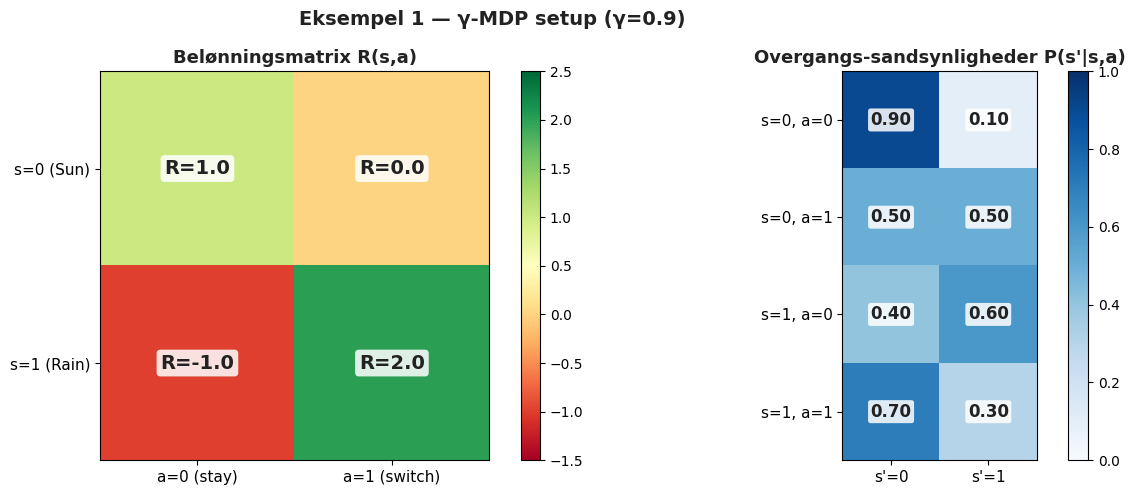

In [2]:
# === Eksempel 1: Visualiser belønningstabel og overgangsmatricer ===
P1 = np.array([
    [[0.9, 0.1], [0.5, 0.5]],   # s=0: actions 0 (stay), 1 (switch)
    [[0.4, 0.6], [0.7, 0.3]],   # s=1: actions 0 (stay), 1 (switch)
])
R1 = np.array([[1.0, 0.0],
               [-1.0, 2.0]])
gamma1 = 0.9

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Belønningsmatrix
ax = axes[0]
im = ax.imshow(R1, cmap='RdYlGn', vmin=-1.5, vmax=2.5)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['a=0 (stay)', 'a=1 (switch)'], fontsize=11)
ax.set_yticklabels(['s=0 (Sun)', 's=1 (Rain)'], fontsize=11)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'R={R1[i, j]:.1f}', ha='center', va='center',
                fontsize=14, fontweight='bold', color='#222', zorder=10,
                bbox=dict(boxstyle='round,pad=0.2',
                          facecolor='white', edgecolor='none', alpha=0.85))
ax.set_title('Belønningsmatrix R(s,a)', fontsize=13, color='#222')
plt.colorbar(im, ax=ax, fraction=0.046)

# Overgangs-heatmap
ax = axes[1]
P_flat = np.zeros((4, 2))
labels_y = []
for s in range(2):
    for a in range(2):
        P_flat[s * 2 + a] = P1[s, a]
        labels_y.append(f's={s}, a={a}')
im2 = ax.imshow(P_flat, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks([0, 1]); ax.set_yticks(range(4))
ax.set_xticklabels(["s'=0", "s'=1"], fontsize=11)
ax.set_yticklabels(labels_y, fontsize=11)
for i in range(4):
    for j in range(2):
        ax.text(j, i, f'{P_flat[i, j]:.2f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color='#222', zorder=10,
                bbox=dict(boxstyle='round,pad=0.15',
                          facecolor='white', edgecolor='none', alpha=0.85))
ax.set_title("Overgangs-sandsynligheder P(s'|s,a)", fontsize=13, color='#222')
plt.colorbar(im2, ax=ax, fraction=0.046)

fig.suptitle(f'Eksempel 1 — γ-MDP setup (γ={gamma1})',
             fontsize=14, fontweight='bold', color='#222')
plt.tight_layout(); plt.show()

=== Resultater ===

  Metode                      V*(0)      V*(1)   π*(0)  π*(1)   iter
  ---------------------- ---------- ----------  ------ ------  -----
  Value iteration         11.097561  12.317073       0      1    221
  Policy iteration        11.097561  12.317073       0      1      2
  Analytisk (matrix)      11.097561  12.317073       0      1      -

  Konsistenstjek:
    ‖V_VI - V_an‖_∞ = 8.68e-10
    ‖V_VI - V_PI‖_∞ = 8.68e-10
    π_VI == π_PI:    True


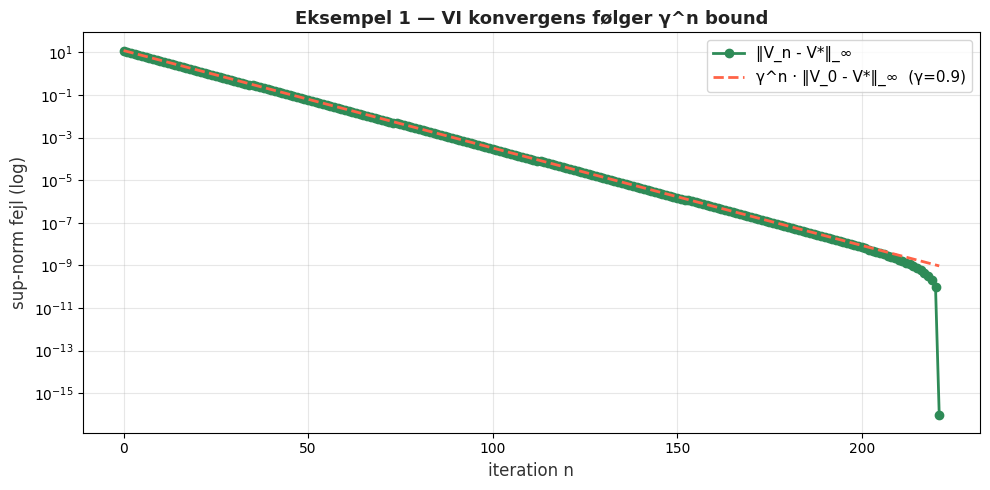

In [3]:
# === Eksempel 1: Løs MDP'en på tre måder og sammenlign ===

# (1) Value iteration
V_vi, pi_vi, n_vi, hist_vi = value_iteration(P1, R1, gamma1, tol=1e-10)

# (2) Policy iteration
V_pi, pi_pi, n_pi, _ = policy_iteration(P1, R1, gamma1)

# (3) Analytisk: brug greedy politik fra VI og bekræft via matrix-inversion
V_an = policy_eval_matrix(pi_vi, P1, R1, gamma1)

print('=== Resultater ===\n')
print(f"  {'Metode':<22} {'V*(0)':>10} {'V*(1)':>10}  {'π*(0)':>6} {'π*(1)':>6}  {'iter':>5}")
print(f"  {'-'*22} {'-'*10} {'-'*10}  {'-'*6} {'-'*6}  {'-'*5}")
print(f"  {'Value iteration':<22} {V_vi[0]:>10.6f} {V_vi[1]:>10.6f}"
      f"  {pi_vi[0]:>6} {pi_vi[1]:>6}  {n_vi:>5}")
print(f"  {'Policy iteration':<22} {V_pi[0]:>10.6f} {V_pi[1]:>10.6f}"
      f"  {pi_pi[0]:>6} {pi_pi[1]:>6}  {n_pi:>5}")
print(f"  {'Analytisk (matrix)':<22} {V_an[0]:>10.6f} {V_an[1]:>10.6f}"
      f"  {pi_vi[0]:>6} {pi_vi[1]:>6}  {'-':>5}")

print(f"\n  Konsistenstjek:")
print(f"    ‖V_VI - V_an‖_∞ = {np.max(np.abs(V_vi - V_an)):.2e}")
print(f"    ‖V_VI - V_PI‖_∞ = {np.max(np.abs(V_vi - V_pi)):.2e}")
print(f"    π_VI == π_PI:    {np.array_equal(pi_vi, pi_pi)}")

# Konvergensplot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
errs = np.max(np.abs(hist_vi - V_vi), axis=1)
ax.semilogy(range(len(errs)), errs + 1e-16, 'o-',
            color='#2E8B57', linewidth=2, markersize=6,
            label='‖V_n - V*‖_∞')
# Teoretisk γ^n bound (med initial fejl)
init_err = errs[0]
ax.semilogy(range(len(errs)), init_err * gamma1**np.arange(len(errs)),
            '--', color='#FF6347', linewidth=2,
            label=f'γ^n · ‖V_0 - V*‖_∞  (γ={gamma1})')
ax.set_xlabel('iteration n', fontsize=12, color='#333')
ax.set_ylabel('sup-norm fejl (log)', fontsize=12, color='#333')
ax.set_title('Eksempel 1 — VI konvergens følger γ^n bound',
             fontsize=13, fontweight='bold', color='#222')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

### ✅ Konklusion / Conclusion — Eksempel 1

**DK:** Alle tre metoder giver **identisk** $V^*$ og $\pi^*$ (op til numerisk præcision). VI konvergerer geometrisk med rate $\gamma = 0.9$ — log-plottet viser præcis dette. PI terminerer i meget få iterationer (ofte 2-3) fordi den eksakte politik-evaluering "springer" til den optimale værdi for den valgte politik. Den analytiske matrix-inversion virker fordi vi kender den optimale politik.

**EN:** All three methods give identical $V^*$ and $\pi^*$. VI converges geometrically at rate $\gamma$. PI terminates in very few iterations because exact evaluation jumps to the optimal value for the current policy.

> **Take-away:** Dette er den **kanoniske** trinvise sammenligning af γ-MDP løsningsmetoder. Geometrisk konvergens er ikke en metafor — det er bogstaveligt $\gamma^n$.

## Eksempel 2: Kontraktion in action / Contraction in Action

**DK:** Vi viser empirisk at $\|T^* V - T^* V'\|_\infty \leq \gamma \|V - V'\|_\infty$ ved at:

1. Generere mange tilfældige par $(V, V')$ i $\mathbb{R}^{|\mathcal{S}|}$.
2. Beregne både siderne af uligheden.
3. Plotte dem mod hinanden — alle punkter skal ligge under linjen $y = \gamma x$.

Vi bruger MDP'en fra eksempel 1 (med $\gamma = 0.9$).

**EN:** Empirically demonstrate the contraction property by sampling many $(V, V')$ pairs and plotting both sides of the inequality.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 2

**ASCII billede af kontraktion / contraction picture:**

```
      input-rummet (V ∈ ℝ²)              output-rummet (T*V ∈ ℝ²)
      ──────────────────              ────────────────────
           V •───────────► T*───► • T*V
           │    distance d            │ distance ≤ γ·d
           V'•───────────► T*───► • T*V'

           ↑                              ↓
        ││V-V'││₊ = d              ││T*V - T*V'││₊ = d'  med d' ≤ γ·d
```

```mermaid
flowchart LR
    V["V (input)"] --> T1["T*"] --> TV["T*V"]
    Vp["V' (input)"] --> T2["T*"] --> TVp["T*V'"]
    TV -.diff.-> CMP["‖T*V - T*V'‖_∞"]
    TVp -.diff.-> CMP
    V -.diff.-> ORIG["‖V - V'‖_∞"]
    Vp -.diff.-> ORIG
    CMP --> CHECK{"≤ γ · ‖V - V'‖_∞ ?"}
    ORIG --> CHECK
    style CHECK fill:#FFD700,stroke:#333,color:#333
```

**Kontraktions-uligheden / contraction inequality:**

$$
\frac{\|T^* V - T^* V'\|_\infty}{\|V - V'\|_\infty} \;\leq\; \gamma
$$

— alle punkter under linjen $y = \gamma x$ i et scatter-plot.

**Forventning / Expectation:**

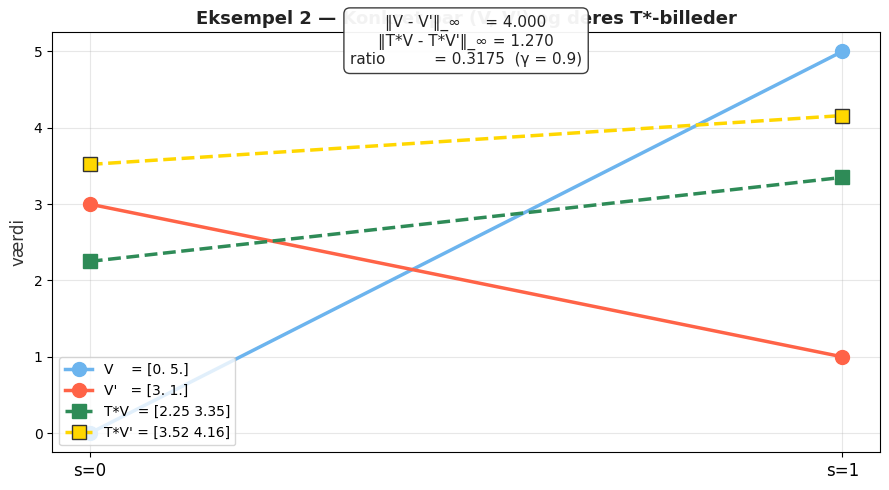

In [4]:
# === Eksempel 2: Visualisering — illustration af ‖V - V'‖_∞ ===
# Vi viser én konkret par (V, V') og deres T*-billeder for at give intuition.

V_a = np.array([0.0, 5.0])
V_b = np.array([3.0, 1.0])
TV_a, _ = bellman_optimality(V_a, P1, R1, gamma1)
TV_b, _ = bellman_optimality(V_b, P1, R1, gamma1)

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
xs = np.array([0, 1])
ax.plot(xs, V_a, 'o-', color='#6CB4EE', linewidth=2.5, markersize=10,
        label=f'V    = {V_a}')
ax.plot(xs, V_b, 'o-', color='#FF6347', linewidth=2.5, markersize=10,
        label=f"V'   = {V_b}")
ax.plot(xs, TV_a, 's--', color='#2E8B57', linewidth=2.5, markersize=10,
        label=f'T*V  = {TV_a.round(3)}')
ax.plot(xs, TV_b, 's--', color='#FFD700', linewidth=2.5, markersize=10,
        markeredgecolor='#333',
        label=f"T*V' = {TV_b.round(3)}")

dist_in  = np.max(np.abs(V_a - V_b))
dist_out = np.max(np.abs(TV_a - TV_b))
ratio = dist_out / dist_in if dist_in > 0 else float('nan')

ax.text(0.5, ax.get_ylim()[1] * 0.92,
        f'‖V - V\'‖_∞     = {dist_in:.3f}\n'
        f'‖T*V - T*V\'‖_∞ = {dist_out:.3f}\n'
        f'ratio          = {ratio:.4f}  (γ = {gamma1})',
        ha='center', fontsize=11, color='#222', zorder=10,
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='white', edgecolor='#333', alpha=0.95))

ax.set_xticks([0, 1]); ax.set_xticklabels(['s=0', 's=1'], fontsize=12)
ax.set_ylabel('værdi', fontsize=12, color='#333')
ax.set_title('Eksempel 2 — Konkret par (V, V\') og deres T*-billeder',
             fontsize=13, fontweight='bold', color='#222')
ax.grid(alpha=0.3); ax.legend(fontsize=10, loc='lower left')
plt.tight_layout(); plt.show()

=== Empirisk verifikation af kontraktion (γ = 0.9) ===
  N = 2000 tilfældige par (V, V')
  max ratio observeret:    0.899982
  middel ratio:            0.546452
  γ (teoretisk øvre bound): 0.900000
  ✅ alle ratios ≤ γ:       True


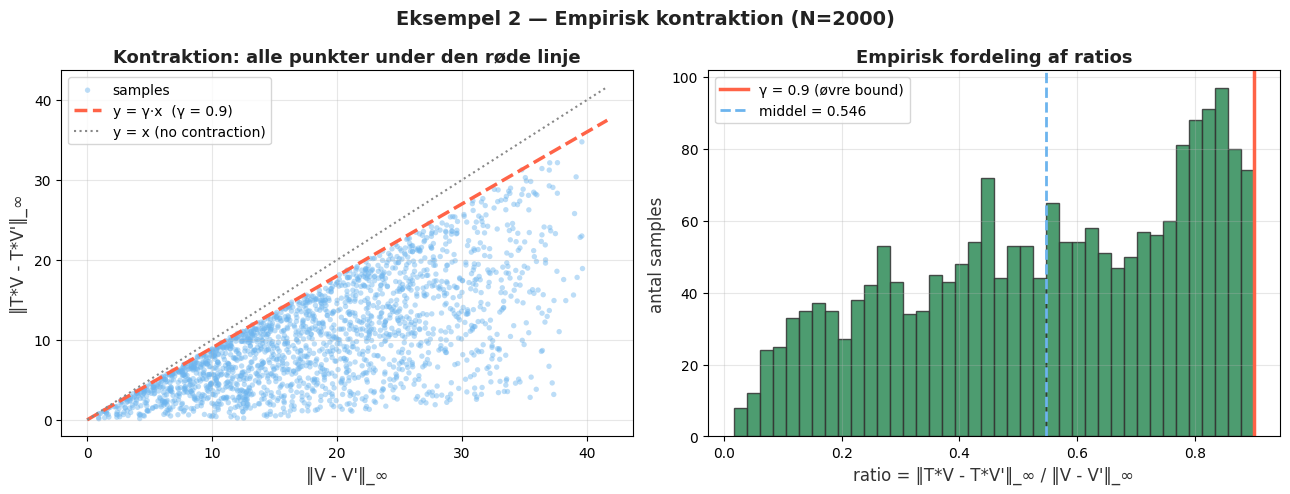

In [5]:
# === Eksempel 2: Sample mange par (V, V') og verificér kontraktion ===
rng = np.random.default_rng(42)
N_SAMPLES = 2000
V_RANGE = 20.0   # sample i [-V_RANGE, V_RANGE]^S

S_dim = P1.shape[0]
in_dists  = np.zeros(N_SAMPLES)
out_dists = np.zeros(N_SAMPLES)

for k in range(N_SAMPLES):
    V = rng.uniform(-V_RANGE, V_RANGE, size=S_dim)
    Vp = rng.uniform(-V_RANGE, V_RANGE, size=S_dim)
    TV, _  = bellman_optimality(V, P1, R1, gamma1)
    TVp, _ = bellman_optimality(Vp, P1, R1, gamma1)
    in_dists[k]  = np.max(np.abs(V - Vp))
    out_dists[k] = np.max(np.abs(TV - TVp))

ratios = out_dists / np.maximum(in_dists, 1e-12)

print(f'=== Empirisk verifikation af kontraktion (γ = {gamma1}) ===')
print(f'  N = {N_SAMPLES} tilfældige par (V, V\')')
print(f'  max ratio observeret:    {ratios.max():.6f}')
print(f'  middel ratio:            {ratios.mean():.6f}')
print(f'  γ (teoretisk øvre bound): {gamma1:.6f}')
print(f'  ✅ alle ratios ≤ γ:       {bool((ratios <= gamma1 + 1e-12).all())}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
ax = axes[0]
ax.scatter(in_dists, out_dists, s=15, alpha=0.45, color='#6CB4EE',
           edgecolors='none', label='samples')
xs = np.linspace(0, in_dists.max() * 1.05, 100)
ax.plot(xs, gamma1 * xs, '--', color='#FF6347', linewidth=2.5,
        label=f'y = γ·x  (γ = {gamma1})')
ax.plot(xs, xs, ':', color='#888', linewidth=1.5, label='y = x (no contraction)')
ax.set_xlabel('‖V - V\'‖_∞', fontsize=12, color='#333')
ax.set_ylabel('‖T*V - T*V\'‖_∞', fontsize=12, color='#333')
ax.set_title('Kontraktion: alle punkter under den røde linje', fontsize=13,
             fontweight='bold', color='#222')
ax.grid(alpha=0.3); ax.legend(fontsize=10)

# Histogram of ratios
ax = axes[1]
ax.hist(ratios, bins=40, color='#2E8B57', edgecolor='#333', alpha=0.85)
ax.axvline(gamma1, color='#FF6347', linewidth=2.5,
           label=f'γ = {gamma1} (øvre bound)')
ax.axvline(ratios.mean(), color='#6CB4EE', linewidth=2,
           linestyle='--', label=f'middel = {ratios.mean():.3f}')
ax.set_xlabel('ratio = ‖T*V - T*V\'‖_∞ / ‖V - V\'‖_∞', fontsize=12, color='#333')
ax.set_ylabel('antal samples', fontsize=12, color='#333')
ax.set_title('Empirisk fordeling af ratios', fontsize=13,
             fontweight='bold', color='#222')
ax.grid(alpha=0.3); ax.legend(fontsize=10)

fig.suptitle(f'Eksempel 2 — Empirisk kontraktion (N={N_SAMPLES})',
             fontsize=14, fontweight='bold', color='#222')
plt.tight_layout(); plt.show()

### ✅ Konklusion / Conclusion — Eksempel 2

**DK:** Histogrammet viser at de fleste ratios ligger **strengt under** $\gamma$ — den øvre bound er konservativ for "tilfældige" par. Worst-case ratio nærmer sig $\gamma$ når argmax-handlingerne for $V$ og $V'$ er identiske og $V - V'$ er konstant (en konstant funktion af $s$). Dette er den geometriske grund til at $T^*$ har et **unikt** fikspunkt: hver iteration formindsker afstanden med faktor $\gamma$.

**EN:** Most ratios are strictly below $\gamma$ — the bound is tight only in a worst-case where the argmax actions agree and $V - V'$ is constant in $s$.

> **Take-away:** Kontraktion er ikke abstrakt — den er målbar og kan simuleres direkte.

## Eksempel 3: Banach empirisk — alle veje fører til V*

**DK:** Banach-fikspunktssætningen siger: **uanset** hvilket startpunkt $V_0$ vi vælger, konvergerer $V_n = T^* V_{n-1}$ mod **samme** $V^*$. Vi tester:

- $V_0 = \mathbf{0}$ (nul-værdier)
- $V_0 = \mathbf{1}$ (alle = 1)
- $V_0 = +\,100 \cdot \mathbf{1}$ (kæmpe optimisme)
- $V_0 = -\,100 \cdot \mathbf{1}$ (kæmpe pessimisme)
- 5 tilfældige $V_0$ uniformt i $[-50, 50]^{|\mathcal{S}|}$

**EN:** Banach: any starting $V_0$ converges to the same $V^*$. We test 9 different initializations on the MDP from Example 1.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 3

**ASCII konvergens-billede / convergence picture:**

```
   start-værdier:    V₀=0    V₀=1    V₀=+100·1    V₀=−100·1    V₀=random
                       │        │        │             │             │
                       ▼        ▼        ▼             ▼             ▼
                    ┌─────────────────────────────────────────┐
                    │         T* iterationer (kontraktion)        │
                    └─────────────────────┬────────────────────┘
                                          ▼
                                       🎯 V*  (samme fikspunkt)
```

```mermaid
flowchart LR
    V0a["V0 = 0"] --> ITER["VI: V ← T*V"]
    V0b["V0 = +100·1"] --> ITER
    V0c["V0 = -100·1"] --> ITER
    V0d["V0 = random"] --> ITER
    ITER --> VSTAR["V* (samme!)"]
    style VSTAR fill:#2E8B57,stroke:#333,color:#fff
    style ITER fill:#FFD700,stroke:#333,color:#333
```

**Konvergens-bound / convergence bound:**

$$
\|V_n - V^*\|_\infty \;\leq\; \gamma^n \, \|V_0 - V^*\|_\infty \quad \forall V_0
$$

— linear shape on log-scale, slope $\log \gamma$.

**Forventning:**

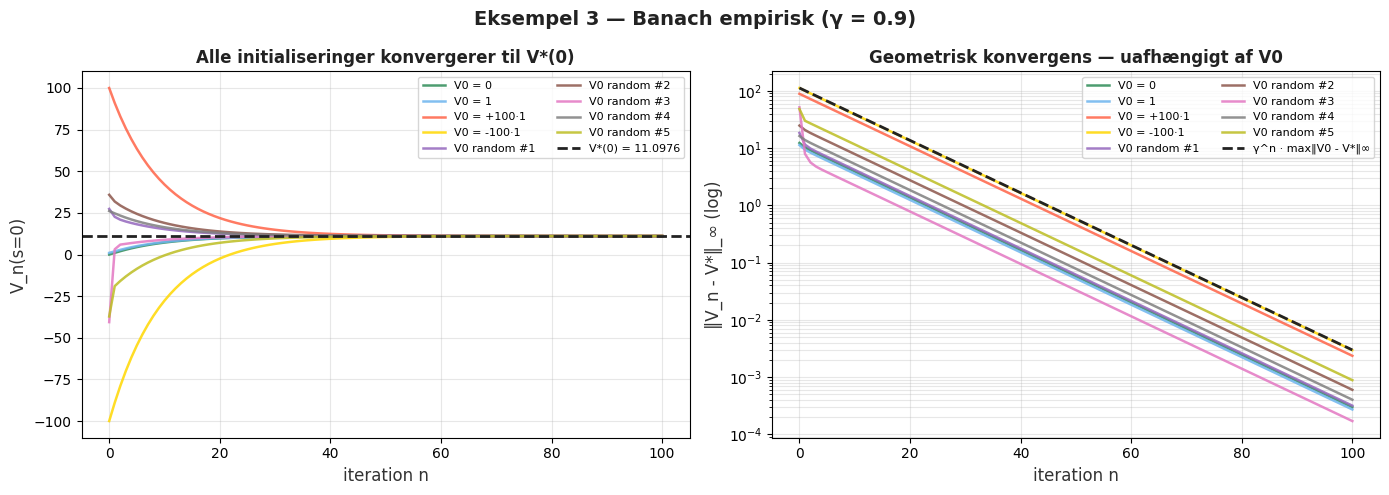

In [6]:
# === Eksempel 3: Plot trajektorierne af V_n(s) for alle initialiseringer ===
def vi_with_init(P, R, gamma, V0, n_iter=120):
    V = V0.copy().astype(float)
    history = [V.copy()]
    for _ in range(n_iter):
        V, _ = bellman_optimality(V, P, R, gamma)
        history.append(V.copy())
    return np.array(history)

V_star = V_vi  # fra eksempel 1
S_dim = P1.shape[0]

rng = np.random.default_rng(42)
init_specs = [
    ('V0 = 0',          np.zeros(S_dim),       '#2E8B57'),
    ('V0 = 1',          np.ones(S_dim),        '#6CB4EE'),
    ('V0 = +100·1',     np.full(S_dim, 100.0), '#FF6347'),
    ('V0 = -100·1',     np.full(S_dim, -100.0),'#FFD700'),
]
for k in range(5):
    v0 = rng.uniform(-50, 50, size=S_dim)
    init_specs.append((f'V0 random #{k+1}', v0, plt.cm.tab10(k + 4)))

N_ITER = 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Venstre: V_n(s=0) trajektorier
ax = axes[0]
for label, V0, color in init_specs:
    hist = vi_with_init(P1, R1, gamma1, V0, n_iter=N_ITER)
    ax.plot(hist[:, 0], color=color, linewidth=1.8, alpha=0.85, label=label)
ax.axhline(V_star[0], color='#222', linewidth=2, linestyle='--',
           label=f'V*(0) = {V_star[0]:.4f}')
ax.set_xlabel('iteration n', fontsize=12, color='#333')
ax.set_ylabel('V_n(s=0)', fontsize=12, color='#333')
ax.set_title('Alle initialiseringer konvergerer til V*(0)',
             fontsize=12, fontweight='bold', color='#222')
ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best', ncol=2)

# Højre: log error
ax = axes[1]
for label, V0, color in init_specs:
    hist = vi_with_init(P1, R1, gamma1, V0, n_iter=N_ITER)
    errs = np.max(np.abs(hist - V_star), axis=1)
    ax.semilogy(errs + 1e-16, color=color, linewidth=1.8, alpha=0.85, label=label)
# Theoretical envelope from largest initial error
init_errs = [np.max(np.abs(V0 - V_star)) for _, V0, _ in init_specs]
ax.semilogy(max(init_errs) * gamma1**np.arange(N_ITER + 1),
            '--', color='#222', linewidth=2,
            label=f'γ^n · max‖V0 - V*‖∞')
ax.set_xlabel('iteration n', fontsize=12, color='#333')
ax.set_ylabel('‖V_n - V*‖_∞ (log)', fontsize=12, color='#333')
ax.set_title('Geometrisk konvergens — uafhængigt af V0',
             fontsize=12, fontweight='bold', color='#222')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='best', ncol=2)

fig.suptitle(f'Eksempel 3 — Banach empirisk (γ = {gamma1})',
             fontsize=14, fontweight='bold', color='#222')
plt.tight_layout(); plt.show()

In [7]:
# === Eksempel 3: Algoritmisk verifikation — alle ender på samme V* ===
N_ITER_TIGHT = 300

print('=== Empirisk Banach-test ===\n')
print(f'  V* (reference, fra eksempel 1) = {V_star.round(6)}\n')

print(f'  {"V0 spec":<22} {"V_300(0)":>12} {"V_300(1)":>12} {"‖·-V*‖∞":>12}')
print(f'  {"-"*22} {"-"*12} {"-"*12} {"-"*12}')

all_close = True
for label, V0, _ in init_specs:
    hist = vi_with_init(P1, R1, gamma1, V0, n_iter=N_ITER_TIGHT)
    Vfinal = hist[-1]
    err = np.max(np.abs(Vfinal - V_star))
    print(f'  {label:<22} {Vfinal[0]:>12.6f} {Vfinal[1]:>12.6f} {err:>12.2e}')
    if err > 1e-6:
        all_close = False

print(f'\n  ✅ alle initialiseringer konvergerer til samme V*: {all_close}')

=== Empirisk Banach-test ===

  V* (reference, fra eksempel 1) = [11.097561 12.317073]

  V0 spec                    V_300(0)     V_300(1)      ‖·-V*‖∞
  ---------------------- ------------ ------------ ------------
  V0 = 0                    11.097561    12.317073     8.68e-10
  V0 = 1                    11.097561    12.317073     8.68e-10
  V0 = +100·1               11.097561    12.317073     8.70e-10
  V0 = -100·1               11.097561    12.317073     8.66e-10
  V0 random #1              11.097561    12.317073     8.69e-10
  V0 random #2              11.097561    12.317073     8.69e-10
  V0 random #3              11.097561    12.317073     8.68e-10
  V0 random #4              11.097561    12.317073     8.69e-10
  V0 random #5              11.097561    12.317073     8.68e-10

  ✅ alle initialiseringer konvergerer til samme V*: True


### ✅ Konklusion / Conclusion — Eksempel 3

**DK:** Alle 9 trajektorier ender på det samme $V^*$, og log-fejlen ligger pænt under den teoretiske $\gamma^n$-envelope. Dette er **Banach** in action: kontraktion $\Rightarrow$ unikt fikspunkt $\Rightarrow$ uafhængighed af startværdi. Bemærk hvordan store initiale fejl (±100) kollapser til praktisk konvergens i ~80-100 iterationer fordi $0.9^{100} \approx 2.7 \times 10^{-5}$.

**EN:** All 9 initializations converge to the same $V^*$. Geometric rate $\gamma$ means even $\pm 100$ initial values reach high accuracy in ~100 iterations.

> **Take-away:** Du behøver ikke en "smart" $V_0$ — Banach garanterer at hvad-som-helst virker.

## Eksempel 4: γ-sensitivitet — myopi vs. langsigt

**DK:** Vi designer en MDP hvor den **optimale politik ændrer sig** med $\gamma$:

- $\mathcal{S} = \{0, 1, 2\}$. State 0 er start, state 2 er en "skat".
- Fra state 0:
  - **Handling 0 (snack):** bliv i state 0, modtag $+1$ pr. step.
  - **Handling 1 (rejs):** gå til state 1 (deterministisk), modtag $0$.
- Fra state 1: deterministisk $\to$ state 2, $0$ reward.
- State 2 er absorberende (sløjfe til sig selv), $+10$ pr. step uanset handling.

Intuition:
- **Lille $\gamma$ (myopisk):** $+1$ nu er bedre end $+10$ langt ude i fremtiden $\Rightarrow$ snack.
- **Stor $\gamma$ (langsigt):** $+10$ for evigt vinder $\Rightarrow$ rejs til skatten.

Vi tester $\gamma \in \{0.1, 0.3, 0.5, 0.8, 0.9, 0.99\}$.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 4

**ASCII MDP-flow / MDP flow:**

```
   START         REJSE        SKAT (absorberende)
  ┌──────┐      ┌──────┐      ┌────────┐
  │  0   │ ────►│  1   │ ────►│   2    │◀─┐
  │ ⭐ +1│←┐    │ r=0  │      │ r=+10  │  │
  └─┬────┘  │    └──────┘      └────────┘  │
    └───────┘   snack: bliv,                  │
   r=+1 hver step (snack)                        │
                                                 └ self-loop r=+10
```

```mermaid
graph LR
    S0(("0 = start")) -->|"a=0 snack: +1"| S0
    S0 -->|"a=1 rejs: 0"| S1(("1 = vej"))

    S1 -->|"any: 0"| S2(("2 = skat: +10/step"))**Crossover:** $\pi_{\text{rejs}}$ vinder når $10\gamma^2 > 1$, dvs. $\gamma > 1/\sqrt{10} \approx 0.316$.

    S2 -->|"any: +10"| S2

    style S0 fill:#FFD700,stroke:#333,color:#333- $\pi_{\text{rejs}}$: $V(0) = 0 + \gamma \cdot 0 + \gamma^2 \cdot \frac{10}{1-\gamma} = \frac{10\gamma^2}{1-\gamma}$

    style S1 fill:#E0E0E0,stroke:#333,color:#333- $\pi_{\text{snack}}$: $V(0) = 1 + \gamma V(0) = \frac{1}{1-\gamma}$

    style S2 fill:#2E8B57,stroke:#333,color:#fff

```**Closed-form for begge politikker (start fra state 0):**


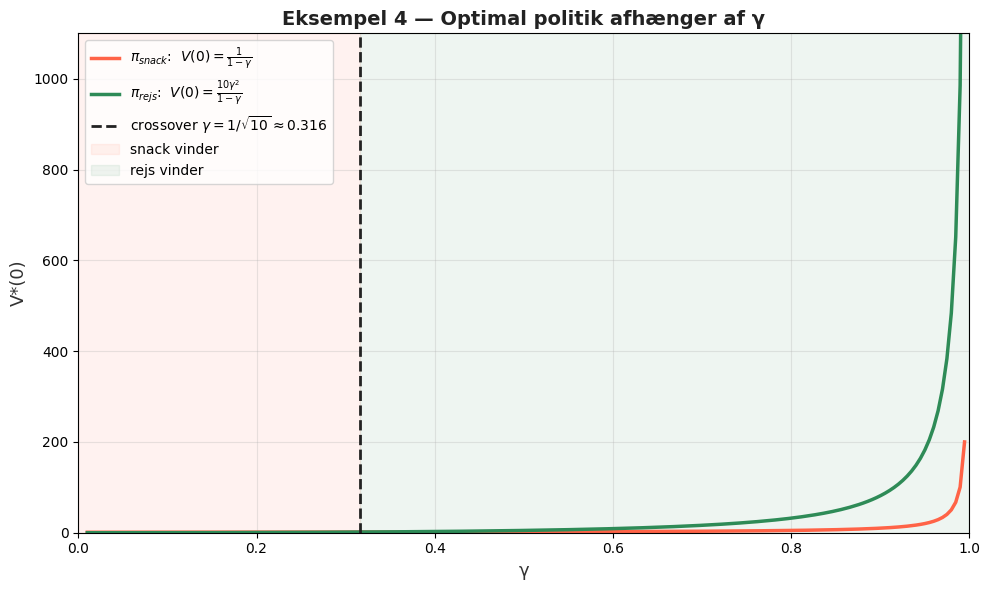

In [8]:
# === Eksempel 4: Plot V*(0) som funktion af γ for begge politikker ===
gammas_dense = np.linspace(0.01, 0.995, 200)
V_snack = 1.0 / (1.0 - gammas_dense)
V_rejs  = 10.0 * gammas_dense**2 / (1.0 - gammas_dense)

cross = 1.0 / np.sqrt(10.0)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(gammas_dense, V_snack, color='#FF6347', linewidth=2.5,
        label=r'$\pi_{snack}$:  $V(0) = \frac{1}{1-\gamma}$')
ax.plot(gammas_dense, V_rejs, color='#2E8B57', linewidth=2.5,
        label=r'$\pi_{rejs}$:  $V(0) = \frac{10\gamma^2}{1-\gamma}$')
ax.axvline(cross, color='#222', linewidth=2, linestyle='--',
           label=fr'crossover $\gamma = 1/\sqrt{{10}} \approx {cross:.3f}$')
ax.fill_betweenx([0, 1100], 0, cross, color='#FF6347', alpha=0.08,
                 label='snack vinder')
ax.fill_betweenx([0, 1100], cross, 1, color='#2E8B57', alpha=0.08,
                 label='rejs vinder')
ax.set_xlabel('γ', fontsize=13, color='#333')
ax.set_ylabel('V*(0)', fontsize=13, color='#333')
ax.set_title('Eksempel 4 — Optimal politik afhænger af γ',
             fontsize=14, fontweight='bold', color='#222')
ax.set_ylim(0, 1100); ax.set_xlim(0, 1)
ax.grid(alpha=0.3); ax.legend(fontsize=10, loc='upper left')
plt.tight_layout(); plt.show()

In [9]:
# === Eksempel 4: Numerisk via VI for diskrete γ-værdier ===
# MDP definition: 3 states, 2 actions
P4 = np.zeros((3, 2, 3))
# State 0: a=0 (snack) → bliv, a=1 (rejs) → state 1
P4[0, 0, 0] = 1.0
P4[0, 1, 1] = 1.0
# State 1: begge handlinger → state 2 (deterministisk vej)
P4[1, 0, 2] = 1.0
P4[1, 1, 2] = 1.0
# State 2: absorberende
P4[2, 0, 2] = 1.0
P4[2, 1, 2] = 1.0

R4 = np.zeros((3, 2))
R4[0, 0] = 1.0   # snack
R4[0, 1] = 0.0   # rejs koster
R4[1, 0] = 0.0; R4[1, 1] = 0.0
R4[2, 0] = 10.0; R4[2, 1] = 10.0   # skat

gammas_test = [0.1, 0.3, 0.5, 0.8, 0.9, 0.99]
print('=== Numerisk VI på γ-sensitivitets-MDP ===\n')
print(f'  {"γ":>6} | {"V*(0)":>10} {"V*(1)":>10} {"V*(2)":>10} | '
      f'{"π*(0)":>14} {"V_snack(0)":>12} {"V_rejs(0)":>12}')
print('  ' + '-' * 92)
action_names = {0: 'snack', 1: 'rejs'}
for g in gammas_test:
    V, pi, _, _ = value_iteration(P4, R4, g, tol=1e-10)
    Vs = 1.0 / (1.0 - g)
    Vr = 10.0 * g**2 / (1.0 - g)
    print(f'  {g:>6.2f} | {V[0]:>10.3f} {V[1]:>10.3f} {V[2]:>10.3f} | '
          f'{action_names[pi[0]]:>14} {Vs:>12.3f} {Vr:>12.3f}')

=== Numerisk VI på γ-sensitivitets-MDP ===

       γ |      V*(0)      V*(1)      V*(2) |          π*(0)   V_snack(0)    V_rejs(0)
  --------------------------------------------------------------------------------------------
    0.10 |      1.111      1.111     11.111 |          snack        1.111        0.111
    0.30 |      1.429      4.286     14.286 |          snack        1.429        1.286
    0.50 |      5.000     10.000     20.000 |           rejs        2.000        5.000
    0.80 |     32.000     40.000     50.000 |           rejs        5.000       32.000
    0.90 |     81.000     90.000    100.000 |           rejs       10.000       81.000
    0.99 |    980.100    990.000   1000.000 |           rejs      100.000      980.100


### ✅ Konklusion / Conclusion — Eksempel 4

**DK:** Ved $\gamma = 0.1, 0.3$ vinder **snack** ($\pi^*(0) = 0$); ved $\gamma \geq 0.5$ vinder **rejs** ($\pi^*(0) = 1$). Crossover ligger ved $\gamma = 1/\sqrt{10} \approx 0.316$ — præcis som den analytiske formel forudsiger. $\gamma$ er ikke bare en konvergens-knap; det er en **modellering-knap** der koder agentens "tålmodighed".

**EN:** Crossover at $\gamma = 1/\sqrt{10} \approx 0.316$ matches the analytic formula. $\gamma$ encodes agent patience — choosing it is a modelling decision.

> **Take-away:** Lille $\gamma$ $\Rightarrow$ myopisk; stor $\gamma$ $\Rightarrow$ langsigt. Den optimale politik kan **kvalitativt** ændre sig.

## Eksempel 5: 4×4 Gridworld med fælder — γ påvirker politikken

**DK:** Vi løser et **stokastisk gridworld**:

- 4×4 grid; agenten starter i $(0,0)$ (top-venstre).
- Mål i $(3,3)$ (bottom-højre): reward $+10$, absorberende.
- Fælde i $(1,2)$: reward $-10$, absorberende.
- Step-cost: $-0.1$ pr. ikke-terminal step.
- Handlinger: $\{$op, ned, venstre, højre$\}$. Stokastik: handling lykkes med sandsynlighed $0.8$; med sandsynlighed $0.1$ slipper agenten 90° til hver side. Bevæger sig ind i en mur $\Rightarrow$ bliver i samme felt.

Vi sammenligner $V^*$ og $\pi^*$ for $\gamma = 0.5$ (myopisk) og $\gamma = 0.99$ (langsigt).

**EN:** Stochastic 4×4 gridworld with goal +10, trap −10, step cost −0.1, 0.8/0.1/0.1 slip. Compare γ=0.5 vs γ=0.99.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 5

```
+----+----+----+----+
| S  |    |    |    |   row 0  (S = start)
+----+----+----+----+
|    |    | T  |    |   row 1  (T = trap, -10)
+----+----+----+----+
|    |    |    |    |   row 2
+----+----+----+----+
|    |    |    | G  |   row 3  (G = goal, +10)
+----+----+----+----+
```

### LaTeX overgangs-struktur / transition structure

For enhver ikke-terminal $(s,a)$:

$$
P(s'\mid s, a) \;=\; \underbrace{0.8}_{\text{intended}}\cdot \mathbb{1}\{s' = s + \Delta_a\} \;+\; \underbrace{0.1}_{\text{slip CCW}}\cdot \mathbb{1}\{s' = s + \Delta_a^{\perp 1}\} \;+\; \underbrace{0.1}_{\text{slip CW}}\cdot \mathbb{1}\{s' = s + \Delta_a^{\perp 2}\}
$$

$$
r(s,a) \;=\; \underbrace{-0.1}_{\text{step cost}} \;+\; \sum_{s'} P(s'\mid s,a)\cdot \bigl(R_{\text{enter}}(s') - (-0.1)\bigr), \quad R_{\text{enter}}(\text{G}) = +10,\; R_{\text{enter}}(\text{T}) = -10
$$

```mermaid
flowchart LR
    subgraph "Stokastisk handling"
        A["agenten vælger 'højre'"] --> B1["0.8: faktisk højre"]
        A --> B2["0.1: slipper op"]
        A --> B3["0.1: slipper ned"]
    end
    style A fill:#FFD700,stroke:#333,color:#333
```

**Forventet observation:**

- $\gamma = 0.99$: $V^*$-værdier er store og glidende; policy går mere "konservativt" udenom.
- $\gamma = 0.5$: $V^*$-værdier er små (futur diskonteres hårdt), policy går nok stadig udenom fælden.

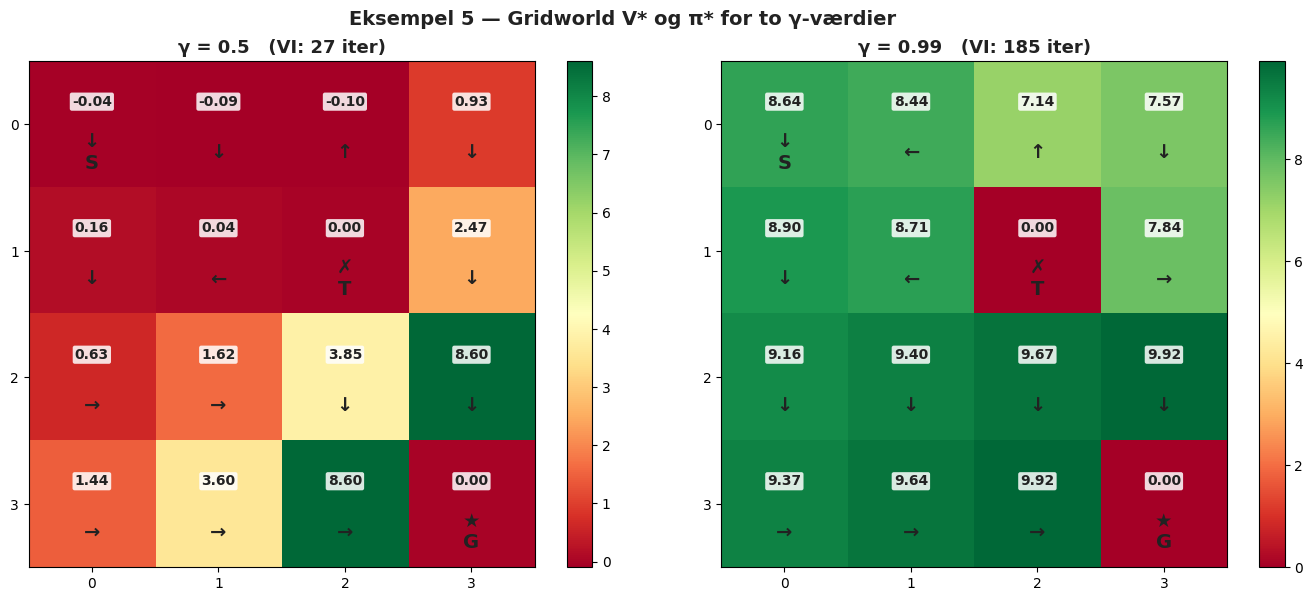

In [10]:
# === Eksempel 5: Byg gridworld MDP ===
GRID_R, GRID_C = 4, 4
N_STATES = GRID_R * GRID_C   # 16
N_ACTIONS = 4
ACTIONS = {0: 'op', 1: 'ned', 2: 'venstre', 3: 'højre'}
ARROWS  = {0: '↑', 1: '↓', 2: '←', 3: '→'}
DELTAS  = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
PERP    = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}  # perpendiculars

START   = (0, 0)
GOAL    = (3, 3)
TRAP    = (1, 2)
STEP_COST = -0.1
GOAL_R    = 10.0
TRAP_R    = -10.0
SLIP_PROB = 0.1   # each side

def rc_to_s(r, c): return r * GRID_C + c
def s_to_rc(s):    return divmod(s, GRID_C)

def step(r, c, a):
    """Deterministisk skridt (med vægbegrænsning)."""
    dr, dc = DELTAS[a]
    nr, nc = r + dr, c + dc
    if 0 <= nr < GRID_R and 0 <= nc < GRID_C:
        return nr, nc
    return r, c   # bumper into wall

P5 = np.zeros((N_STATES, N_ACTIONS, N_STATES))
R5 = np.zeros((N_STATES, N_ACTIONS))

for r in range(GRID_R):
    for c in range(GRID_C):
        s = rc_to_s(r, c)
        if (r, c) == GOAL or (r, c) == TRAP:
            # absorberende, reward = 0 (terminal-reward modtages ved entry)
            for a in range(N_ACTIONS):
                P5[s, a, s] = 1.0
                R5[s, a] = 0.0
            continue
        for a in range(N_ACTIONS):
            # 0.8 intended
            r1, c1 = step(r, c, a)
            P5[s, a, rc_to_s(r1, c1)] += 0.8
            # 0.1 each perpendicular slip
            for ap in PERP[a]:
                r2, c2 = step(r, c, ap)
                P5[s, a, rc_to_s(r2, c2)] += SLIP_PROB
            # Reward: step cost + entry-reward for goal/trap
            exp_r = STEP_COST
            for s_next in range(N_STATES):
                if P5[s, a, s_next] > 0:
                    rn, cn = s_to_rc(s_next)
                    if (rn, cn) == GOAL:
                        exp_r += P5[s, a, s_next] * (GOAL_R - STEP_COST)
                    elif (rn, cn) == TRAP:
                        exp_r += P5[s, a, s_next] * (TRAP_R - STEP_COST)
            R5[s, a] = exp_r

# sanity: rows sum to 1
assert np.allclose(P5.sum(axis=2), 1.0), "P5 rows must sum to 1"

# === Solve for two values of γ ===
gammas_grid = [0.5, 0.99]
results = {}
for g in gammas_grid:
    V, pi, n_iter, _ = value_iteration(P5, R5, g, tol=1e-9, max_iter=20_000)
    results[g] = (V.reshape(GRID_R, GRID_C), pi.reshape(GRID_R, GRID_C), n_iter)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, g in zip(axes, gammas_grid):
    Vgrid, pigrid, n_iter = results[g]
    im = ax.imshow(Vgrid, cmap='RdYlGn', vmin=Vgrid.min(), vmax=Vgrid.max())
    for r in range(GRID_R):
        for c in range(GRID_C):
            label = f'{Vgrid[r, c]:.2f}'
            arrow = ARROWS[int(pigrid[r, c])]
            cellname = ''
            if (r, c) == START: cellname = '\nS'
            elif (r, c) == GOAL: cellname = '\nG'; arrow = '★'
            elif (r, c) == TRAP: cellname = '\nT'; arrow = '✗'
            ax.text(c, r - 0.18, label, ha='center', va='center',
                    fontsize=10, fontweight='bold', color='#222', zorder=10,
                    bbox=dict(boxstyle='round,pad=0.15',
                              facecolor='white', edgecolor='none', alpha=0.85))
            ax.text(c, r + 0.22, arrow + cellname, ha='center', va='center',
                    fontsize=14, fontweight='bold', color='#222', zorder=10)
    ax.set_xticks(range(GRID_C)); ax.set_yticks(range(GRID_R))
    ax.set_title(f'γ = {g}   (VI: {n_iter} iter)',
                 fontsize=13, fontweight='bold', color='#222')
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle('Eksempel 5 — Gridworld V* og π* for to γ-værdier',
             fontsize=14, fontweight='bold', color='#222')
plt.tight_layout(); plt.show()

In [11]:
# === Eksempel 5: Skanning over γ — antal iterationer + politik-stabilitet ===
gammas_scan = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995]
print('=== Gridworld γ-scan ===\n')
print(f'  {"γ":>6} | {"V*(start)":>10} {"V*(naer goal)":>14} | '
      f'{"VI iter":>8} | {"π*(start)":>10}')
print('  ' + '-' * 70)
prev_pi = None
for g in gammas_scan:
    V, pi, n_iter, _ = value_iteration(P5, R5, g, tol=1e-9, max_iter=20_000)
    Vgrid = V.reshape(GRID_R, GRID_C)
    pigrid = pi.reshape(GRID_R, GRID_C)
    print(f'  {g:>6.3f} | {Vgrid[0,0]:>10.4f} {Vgrid[3,2]:>14.4f} | '
          f'{n_iter:>8} | {ARROWS[int(pigrid[0,0])]:>10}')

# Effektiv horisont 1/(1-γ)
print('\n  Effektiv horisont H ≈ 1/(1-γ):')
for g in gammas_scan:
    print(f'    γ = {g:>5.3f}  →  H ≈ {1.0/(1.0-g):>8.1f} steps')

=== Gridworld γ-scan ===

       γ |  V*(start)  V*(naer goal) |  VI iter |  π*(start)
  ----------------------------------------------------------------------
   0.100 |    -0.1111         8.0669 |       10 |          ↓
   0.250 |    -0.1292         8.2297 |       16 |          ↓
   0.500 |    -0.0418         8.6028 |       27 |          ↓
   0.750 |     1.2348         9.1458 |       30 |          ↓
   0.900 |     4.3674         9.5907 |       39 |          ↓
   0.950 |     6.4081         9.7665 |       86 |          ↓
   0.990 |     8.6364         9.9192 |      185 |          ↓
   0.995 |     8.9602         9.9391 |      198 |          ↓

  Effektiv horisont H ≈ 1/(1-γ):
    γ = 0.100  →  H ≈      1.1 steps
    γ = 0.250  →  H ≈      1.3 steps
    γ = 0.500  →  H ≈      2.0 steps
    γ = 0.750  →  H ≈      4.0 steps
    γ = 0.900  →  H ≈     10.0 steps
    γ = 0.950  →  H ≈     20.0 steps
    γ = 0.990  →  H ≈    100.0 steps
    γ = 0.995  →  H ≈    200.0 steps


### ✅ Konklusion / Conclusion — Eksempel 5

**DK:** $V^*$-værdierne vokser markant med $\gamma$ (de er domineret af $R_{\max}/(1-\gamma)$), og antallet af VI-iterationer eksploderer når $\gamma \to 1$. Politikken peger i begge tilfælde **udenom** fælden — fælden er for "dyr" selv ved myopisk diskontering. Effektiv horisont $H \approx 1/(1-\gamma)$ giver intuition: $\gamma = 0.99 \Rightarrow H \approx 100$ steps før belønninger "glemmes".

**EN:** $V^*$ scales as $1/(1-\gamma)$. VI iteration count blows up as $\gamma \to 1$. Effective horizon $H \approx 1/(1-\gamma)$ gives intuition.

> **Take-away:** $\gamma$ tæt på 1 $\Rightarrow$ langsigtet planlægning, men dyrere at løse.

## Eksempel 6: Policy iteration — monoton forbedring i praksis

**DK:** Vi viser empirisk at policy iteration giver **strictly pointwise** monotont voksende værdifunktioner $V^{\pi_0} \leq V^{\pi_1} \leq V^{\pi_2} \leq \dots \leq V^*$, indtil politikken stabiliseres.

Vi bruger en lille 3-state MDP og plotter $V^{\pi_k}(s)$ for alle $k$ og alle $s$.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 6

**ASCII PI-løkken / PI loop diagram:**

```
   ┌────────────────┐         ┌──────────────────┐
   │   1. EVAL      │         │   2. IMPROVE     │
   │  V^π_k =       │ ──────► │  π_{k+1}(s) =    │
   │  (I-γP_π)⁻¹·r  │         │  greedy(V^π_k)   │
   └────────┬───────┘         └────────┬─────────┘
            ▲                          │
            │   π_{k+1} ≠ π_k          │
            └──────────────────────────┘
                                       │  π_{k+1} = π_k
                                       ▼
                              ┌────────────────┐
                              │  ✅ π* fundet  │
                              └────────────────┘

   Monotonicitet:  V^π_0  ≤  V^π_1  ≤  ...  ≤  V^π_K  =  V*
```

**Sætning (monotonicitet) / Theorem (monotonicity):** $V^{\pi_{k+1}}(s) \geq V^{\pi_k}(s)$ for alle $s$, med streng ulighed for mindst ét $s$ medmindre $\pi_k = \pi^*$.

```mermaid
flowchart LR
    PI0["π_0 (initial)"] --> EVAL0["evaluér: V^{π_0}"]
    EVAL0 --> IMPR0["greedy: π_1"]
    IMPR0 --> EVAL1["evaluér: V^{π_1}"]
    EVAL1 --> IMPR1["greedy: π_2"]
    IMPR1 --> DOTS["..."]
    DOTS --> STABLE["π_K = π_{K-1}<br/>V^{π_K} = V*"]
    style PI0 fill:#FFD700,stroke:#333,color:#333
    style EVAL0 fill:#6CB4EE,stroke:#333,color:#333
    style EVAL1 fill:#6CB4EE,stroke:#333,color:#333
    style IMPR0 fill:#90EE90,stroke:#333,color:#333
    style IMPR1 fill:#90EE90,stroke:#333,color:#333
    style DOTS fill:#E0E0E0,stroke:#333,color:#333
    style STABLE fill:#2E8B57,stroke:#333,color:#fff
```

**LaTeX — monoton forbedring / monotone improvement:**

$$
\underbrace{V^{\pi_0}}_{\text{start}} \;\leq\; V^{\pi_1} \;\leq\; V^{\pi_2} \;\leq\; \cdots \;\leq\; \underbrace{V^{\pi_K}}_{=\,V^*}
$$

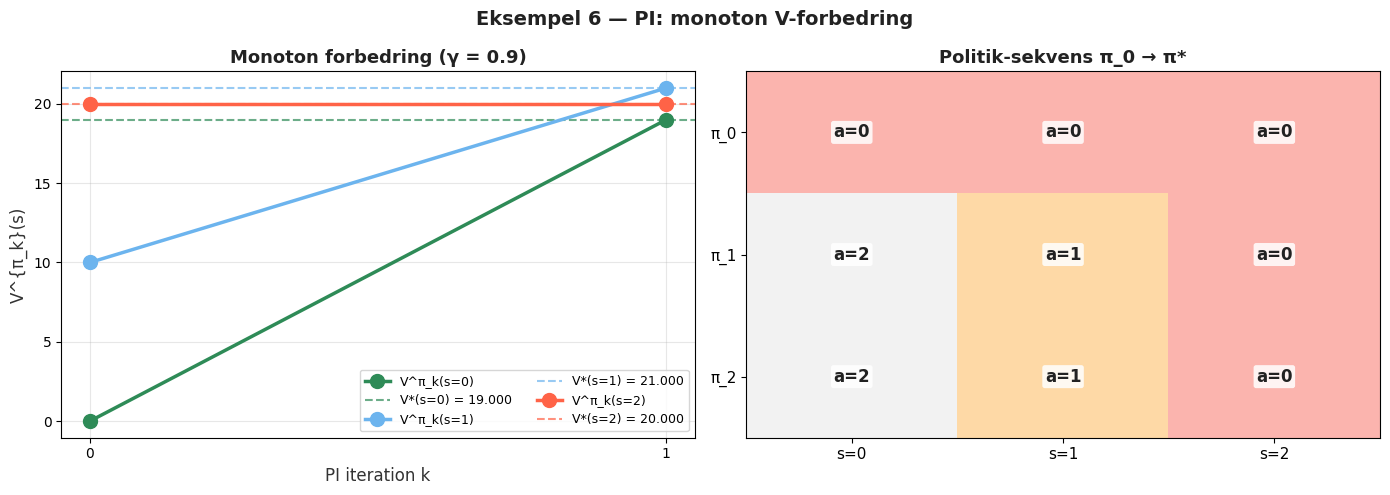

In [12]:
# === Eksempel 6: Visualiser MDP og kør PI med fuld V-historik ===

# 3-state, 3-action MDP konstrueret så PI kræver flere iterationer
S6 = 3; A6 = 3
P6 = np.zeros((S6, A6, S6))
# State 0: a=0 stay (dårlig), a=1 to state 1, a=2 to state 2
P6[0, 0, 0] = 1.0
P6[0, 1, 1] = 1.0
P6[0, 2, 2] = 1.0
# State 1: a=0 stay, a=1 to state 2, a=2 to state 0
P6[1, 0, 1] = 1.0
P6[1, 1, 2] = 1.0
P6[1, 2, 0] = 1.0
# State 2: a=0 stay, a=1 to state 0, a=2 to state 1
P6[2, 0, 2] = 1.0
P6[2, 1, 0] = 1.0
P6[2, 2, 1] = 1.0

R6 = np.array([
    [0.0, -1.0, 1.0],   # state 0: stay 0, to s1 cost 1, to s2 reward 1
    [1.0,  3.0, -2.0],  # state 1
    [2.0,  0.0, -1.0],  # state 2
])
gamma6 = 0.9

# Custom PI med historik
def policy_iteration_history(P, R, gamma, pi0=None, max_iter=50):
    S = P.shape[0]
    pi = np.zeros(S, dtype=int) if pi0 is None else pi0.copy()
    V_hist = []
    pi_hist = [pi.copy()]
    for _ in range(max_iter):
        V = policy_eval_matrix(pi, P, R, gamma)
        V_hist.append(V.copy())
        # greedy improvement
        Q = R + gamma * (P @ V)
        pi_new = Q.argmax(axis=1)
        pi_hist.append(pi_new.copy())
        if np.array_equal(pi_new, pi):
            break
        pi = pi_new
    return np.array(V_hist), pi_hist

# Start fra suboptimal politik (alle 'stay')
pi0 = np.zeros(S6, dtype=int)
V_hist, pi_hist = policy_iteration_history(P6, R6, gamma6, pi0=pi0)
V_star6, pi_star6, _, _ = value_iteration(P6, R6, gamma6, tol=1e-12)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Venstre: V^{π_k}(s) per iteration, en linje pr. state
ax = axes[0]
colors = ['#2E8B57', '#6CB4EE', '#FF6347']
for s in range(S6):
    ax.plot(range(len(V_hist)), V_hist[:, s], 'o-',
            color=colors[s], linewidth=2.5, markersize=10,
            label=f'V^π_k(s={s})')
    ax.axhline(V_star6[s], color=colors[s], linewidth=1.5,
               linestyle='--', alpha=0.7,
               label=f'V*(s={s}) = {V_star6[s]:.3f}')
ax.set_xlabel('PI iteration k', fontsize=12, color='#333')
ax.set_ylabel('V^{π_k}(s)', fontsize=12, color='#333')
ax.set_title(f'Monoton forbedring (γ = {gamma6})',
             fontsize=13, fontweight='bold', color='#222')
ax.set_xticks(range(len(V_hist)))
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='lower right', ncol=2)

# Højre: politikker som heatmap (rækker = iter, kolonner = states)
ax = axes[1]
pi_arr = np.array(pi_hist)
im = ax.imshow(pi_arr, cmap='Pastel1', aspect='auto',
               vmin=0, vmax=A6 - 1)
for k in range(pi_arr.shape[0]):
    for s in range(S6):
        ax.text(s, k, f'a={pi_arr[k, s]}', ha='center', va='center',
                fontsize=12, fontweight='bold', color='#222', zorder=10,
                bbox=dict(boxstyle='round,pad=0.15',
                          facecolor='white', edgecolor='none', alpha=0.85))
ax.set_xticks(range(S6)); ax.set_yticks(range(pi_arr.shape[0]))
ax.set_xticklabels([f's={s}' for s in range(S6)], fontsize=11)
ax.set_yticklabels([f'π_{k}' for k in range(pi_arr.shape[0])], fontsize=11)
ax.set_title('Politik-sekvens π_0 → π*', fontsize=13,
             fontweight='bold', color='#222')

fig.suptitle('Eksempel 6 — PI: monoton V-forbedring',
             fontsize=14, fontweight='bold', color='#222')
plt.tight_layout(); plt.show()

In [13]:
# === Eksempel 6: Verificér monotonicitet pointwise ===
print('=== PI monotonicitets-tabel ===\n')
print(f'  iter k | π_k                  | V^{{π_k}}(0)  V^{{π_k}}(1)  V^{{π_k}}(2)  | Δ vs prev')
print('  ' + '-' * 80)
prev_V = None
for k in range(len(V_hist)):
    Vk = V_hist[k]
    pik = pi_hist[k]
    delta_str = 'init'
    if prev_V is not None:
        diff = Vk - prev_V
        delta_str = f'min Δ = {diff.min():+.4f}, max Δ = {diff.max():+.4f}'
    print(f'  {k:>6} | {str(pik.tolist()):<20} | '
          f'{Vk[0]:>10.4f} {Vk[1]:>10.4f} {Vk[2]:>10.4f}  | {delta_str}')
    prev_V = Vk

# Verificér at Vk+1 ≥ Vk pointwise hele vejen
mono = all((V_hist[k+1] >= V_hist[k] - 1e-12).all() for k in range(len(V_hist) - 1))
print(f'\n  ✅ V^{{π_{{k+1}}}} ≥ V^{{π_k}} pointwise for alle k: {mono}')
print(f'  ✅ slutpolitik π* matcher VI:                     {np.array_equal(pi_hist[-1], pi_star6)}')
print(f'  ✅ slut-V matcher V* fra VI:                      '
      f'{np.allclose(V_hist[-1], V_star6, atol=1e-8)}')

=== PI monotonicitets-tabel ===

  iter k | π_k                  | V^{π_k}(0)  V^{π_k}(1)  V^{π_k}(2)  | Δ vs prev
  --------------------------------------------------------------------------------
       0 | [0, 0, 0]            |     0.0000    10.0000    20.0000  | init
       1 | [2, 1, 0]            |    19.0000    21.0000    20.0000  | min Δ = +0.0000, max Δ = +19.0000

  ✅ V^{π_{k+1}} ≥ V^{π_k} pointwise for alle k: True
  ✅ slutpolitik π* matcher VI:                     True
  ✅ slut-V matcher V* fra VI:                      True


### ✅ Konklusion / Conclusion — Eksempel 6

**DK:** Værdifunktionen vokser monotont i hver state — `min Δ ≥ 0` overalt — indtil PI stabiliserer sig på $\pi^*$. Stabiliseringen sker hurtigt (typisk 2-4 iterationer for små MDP'er), fordi hver evaluering "springer" til den eksakte fixpunkt for den valgte politik (modsat VI's gradvise konvergens).

**EN:** $V^{\pi_k}$ grows pointwise non-decreasing every iteration; PI stabilizes in just a few steps because each evaluation jumps to the exact fixed point.

> **Take-away:** PI's overlegenhed på små problemer kommer fra at undgå VI's geometriske halen.

## Eksempel 7: VI vs PI — iteration count og wall time

**DK:** Vi sammenligner VI og PI på **tilfældigt genererede MDPs** af forskellige størrelser, for $\gamma \in \{0.5, 0.9, 0.99\}$. Vi måler:

- Antal iterationer til konvergens
- Wall-clock tid via `time.time()`

Forventning:
- **PI:** få iterationer (typisk $\leq 5\text{-}10$ uafhængigt af $\gamma$), men hver iteration koster $O(|\mathcal{S}|^3)$ matrix-inversion.
- **VI:** mange iterationer ($\propto \log(1/\epsilon)/\log(1/\gamma)$), hver iteration $O(|\mathcal{S}|^2 |\mathcal{A}|)$. Eksploderer når $\gamma \to 1$.

**EN:** Compare VI vs PI on randomly generated MDPs of varying sizes for several γ values; report iterations and wall time.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 7

**ASCII trade-off-billede / trade-off picture:**

```
   antal iter      VI: ▲ ▲ ▲ ▲ ▲ ▲ ▲ ▲ ▲ ...           PI: ▲ ▲ ▲
                   |  |  |  |  |  |  |  |  |             |  |  |
                   billig pr. iter (O(S²A))           dyr pr. iter (O(S³))
                   billig total ved stor S            dyr total ved stor S
                   antal eksploderer ved γ→1          antal ~ konstant i γ

          best når:  STOR S, lille γ                  LILLE-MID S, γ → 1
```

### LaTeX kompleksitets-tabel / complexity table

$$
\begin{array}{l|cc}
 & \text{VI} & \text{PI} \\ \hline
\text{pr.\ iter} & O(S^2 A) & O(S^3 + S^2 A) \\
\text{antal iter} & O\!\left(\dfrac{\log(1/\varepsilon)}{1-\gamma}\right) & O(\text{få},\;\sim 5\text{-}20) \\
\text{total} & \tilde O\!\left(\dfrac{S^2 A}{1-\gamma}\right) & \tilde O(S^3 \cdot \text{få})
\end{array}
$$

**Forventning / Expectation:** PI vinder på **små** $S$, VI vinder på **store** $S$ (hvor $S^3$-inversion bliver dyr).

```mermaid
flowchart TB
    subgraph VI_box ["VI"]
        V1["mange små iter"] --> V2["O(S²A) pr. iter"]
        V2 --> V3["antal ∝ 1/(1-γ)"]
    end
    subgraph PI_box ["PI"]
        P1["få iter"] --> P2["O(S³) pr. iter"]
        P2 --> P3["antal ~ konstant"]
    end
    style V1 fill:#FF6347,stroke:#333,color:#fff
    style V2 fill:#FFD700,stroke:#333,color:#333
    style V3 fill:#FFD700,stroke:#333,color:#333
    style P1 fill:#2E8B57,stroke:#333,color:#fff
    style P2 fill:#FFD700,stroke:#333,color:#333
    style P3 fill:#90EE90,stroke:#333,color:#333
```

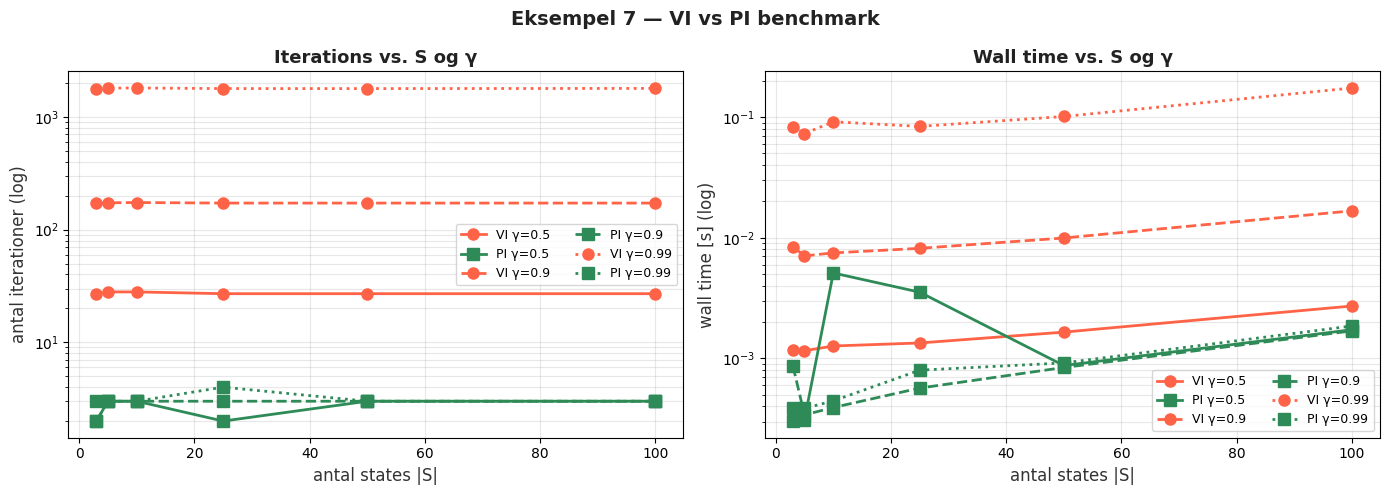

In [14]:
# === Eksempel 7: Plot — iter count og wall time vs S og γ ===
import time

def random_mdp(S, A, seed=0):
    rng = np.random.default_rng(seed)
    P = rng.dirichlet(np.ones(S), size=(S, A))   # rows sum to 1
    R = rng.uniform(-1, 1, size=(S, A))
    return P, R

S_list = [3, 5, 10, 25, 50, 100]
gammas_bench = [0.5, 0.9, 0.99]

results_vi = {g: {'iter': [], 'time': []} for g in gammas_bench}
results_pi = {g: {'iter': [], 'time': []} for g in gammas_bench}

for S in S_list:
    P, R = random_mdp(S, A=4, seed=42)
    for g in gammas_bench:
        # VI
        t0 = time.time()
        _, _, n_vi, _ = value_iteration(P, R, g, tol=1e-8, max_iter=100_000)
        t_vi = time.time() - t0
        results_vi[g]['iter'].append(n_vi)
        results_vi[g]['time'].append(t_vi)
        # PI
        t0 = time.time()
        _, _, n_pi, _ = policy_iteration(P, R, g, max_iter=200)
        t_pi = time.time() - t0
        results_pi[g]['iter'].append(n_pi)
        results_pi[g]['time'].append(t_pi)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iter count
ax = axes[0]
ls_map = {0.5: '-', 0.9: '--', 0.99: ':'}
for g in gammas_bench:
    ax.plot(S_list, results_vi[g]['iter'], 'o' + ls_map[g],
            color='#FF6347', linewidth=2, markersize=8,
            label=f'VI γ={g}')
    ax.plot(S_list, results_pi[g]['iter'], 's' + ls_map[g],
            color='#2E8B57', linewidth=2, markersize=8,
            label=f'PI γ={g}')
ax.set_yscale('log')
ax.set_xlabel('antal states |S|', fontsize=12, color='#333')
ax.set_ylabel('antal iterationer (log)', fontsize=12, color='#333')
ax.set_title('Iterations vs. S og γ', fontsize=13,
             fontweight='bold', color='#222')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9, ncol=2)

# Wall time
ax = axes[1]
for g in gammas_bench:
    ax.plot(S_list, results_vi[g]['time'], 'o' + ls_map[g],
            color='#FF6347', linewidth=2, markersize=8,
            label=f'VI γ={g}')
    ax.plot(S_list, results_pi[g]['time'], 's' + ls_map[g],
            color='#2E8B57', linewidth=2, markersize=8,
            label=f'PI γ={g}')
ax.set_yscale('log')
ax.set_xlabel('antal states |S|', fontsize=12, color='#333')
ax.set_ylabel('wall time [s] (log)', fontsize=12, color='#333')
ax.set_title('Wall time vs. S og γ', fontsize=13,
             fontweight='bold', color='#222')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9, ncol=2)

fig.suptitle('Eksempel 7 — VI vs PI benchmark',
             fontsize=14, fontweight='bold', color='#222')
plt.tight_layout(); plt.show()

In [15]:
# === Eksempel 7: Tabel-resumé ===
print('=== VI vs PI benchmark resultater ===\n')
print(f'  {"|S|":>5} | {"γ":>5} | '
      f'{"VI iter":>8} {"VI time[s]":>11} | '
      f'{"PI iter":>8} {"PI time[s]":>11} | {"vinder (tid)":>14}')
print('  ' + '-' * 80)
for i, S in enumerate(S_list):
    for g in gammas_bench:
        vi_t = results_vi[g]['time'][i]
        pi_t = results_pi[g]['time'][i]
        winner = 'VI' if vi_t < pi_t else 'PI'
        print(f'  {S:>5} | {g:>5.2f} | '
              f'{results_vi[g]["iter"][i]:>8} {vi_t:>11.4f} | '
              f'{results_pi[g]["iter"][i]:>8} {pi_t:>11.4f} | {winner:>14}')

=== VI vs PI benchmark resultater ===

    |S| |     γ |  VI iter  VI time[s] |  PI iter  PI time[s] |   vinder (tid)
  --------------------------------------------------------------------------------
      3 |  0.50 |       27      0.0012 |        2      0.0003 |             PI
      3 |  0.90 |      171      0.0084 |        2      0.0009 |             PI
      3 |  0.99 |     1778      0.0822 |        3      0.0004 |             PI
      5 |  0.50 |       28      0.0012 |        3      0.0003 |             PI
      5 |  0.90 |      173      0.0071 |        3      0.0003 |             PI
      5 |  0.99 |     1803      0.0730 |        3      0.0004 |             PI
     10 |  0.50 |       28      0.0013 |        3      0.0051 |             VI
     10 |  0.90 |      174      0.0075 |        3      0.0004 |             PI
     10 |  0.99 |     1807      0.0914 |        3      0.0004 |             PI
     25 |  0.50 |       27      0.0013 |        2      0.0035 |             VI
     25 |

### ✅ Konklusion / Conclusion — Eksempel 7

**DK:** PI bruger meget få iterationer ($\sim 5\text{-}15$) **uafhængigt af** $\gamma$. VI's antal iterationer eksploderer når $\gamma \to 1$. Wall time afspejler trade-off: PI's $O(S^3)$ matrix-inversion bliver dyrere relativt til VI's $O(S^2 A)$-operationer når $S$ vokser. For meget store MDPs er hybrider (modificeret PI med $k$-step approksimativ evaluering) ofte vinderen.

**EN:** PI iteration count is essentially γ-independent; VI's grows as γ→1. Trade-off: PI's $O(S^3)$ vs VI's $O(S^2 A)$ per iteration.

> **Take-away:** Brug PI for "små + tæt på 1"; VI for "store + langt fra 1"; modified PI for det bedste fra begge verdener.

## Eksempel 8: ε-optimalt stop-kriterium — virker det i praksis?

**DK:** Sætningen siger:

$$\|V_{n+1} - V_n\|_\infty < \delta \;\;\text{med}\;\; \delta = \frac{\epsilon (1-\gamma)}{2 \gamma} \quad\Longrightarrow\quad \|V^{\hat{\pi}} - V^*\|_\infty \leq \epsilon$$

hvor $\hat{\pi}$ er den greedy politik mht. $V_n$.

Vi tester det: kør VI på MDP'en fra eksempel 1 med stop-tærskler $\epsilon \in \{1.0, 0.1, 0.01, 0.001\}$. For hver $\epsilon$:

1. Beregn $\delta = \epsilon(1-\gamma)/(2\gamma)$.
2. Kør VI til $\|V_{n+1} - V_n\|_\infty < \delta$.
3. Beregn greedy $\hat{\pi}$, evaluér $V^{\hat{\pi}}$ analytisk.
4. Mål faktisk fejl $\|V^{\hat{\pi}} - V^*\|_\infty$ og sammenlign med $\epsilon$.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 8

**ASCII bound-pipeline / bound pipeline:**

```
   vælg ε
     │
     ▼
   δ = ε(1−γ)/(2γ)              ← strengt stop-tolerance
     │
     ▼
   kør VI til ‖V_{n+1} − V_n‖_∞ < δ
     │
     ▼
   π̂ = greedy(V_n)
     │
     ▼
   eval V^{π̂} = (I − γ·P_{π̂})⁻¹ · r_{π̂}
     │
     ▼
   mål ‖V^{π̂} − V*‖_∞   →   forventet ≤ ε  ✅
```

Vi forventer at den **faktiske** fejl er **mindre** end $\varepsilon$ (bound'en er konservativ).

```mermaid
flowchart LR
    EPS["vælg ε"] --> DELTA["δ = ε(1-γ)/(2γ)"]
    DELTA --> VI["kør VI til<br/>‖V_{n+1}-V_n‖_∞ < δ"]
    VI --> GREEDY["π̂ = greedy(V_n)"]
    GREEDY --> EVAL["V^{π̂} via matrix-inversion"]
    EVAL --> CHECK["mål ‖V^{π̂}-V*‖_∞"]
    CHECK --> Q{"≤ ε ?"}
    Q -->|ja / yes| OK["✅ inden for bound"]
    Q -->|nej / no| BAD["⚠️ uventet — tjek δ"]
    style EPS fill:#FFD700,stroke:#333,color:#333
    style DELTA fill:#FFD700,stroke:#333,color:#333
    style VI fill:#6CB4EE,stroke:#333,color:#333
    style GREEDY fill:#90EE90,stroke:#333,color:#333
    style EVAL fill:#6CB4EE,stroke:#333,color:#333
    style CHECK fill:#E0E0E0,stroke:#333,color:#333
    style Q fill:#FFD700,stroke:#333,color:#333
    style OK fill:#2E8B57,stroke:#333,color:#fff
    style BAD fill:#FF6347,stroke:#333,color:#fff
```

**LaTeX — bound formel / bound formula:**

$$
\bigl\| V^{\hat\pi} - V^* \bigr\|_\infty \;\leq\; \frac{2\gamma}{1-\gamma}\, \bigl\| V_{n+1} - V_n \bigr\|_\infty \;\leq\; \frac{2\gamma}{1-\gamma}\,\delta \;=\; \varepsilon
$$

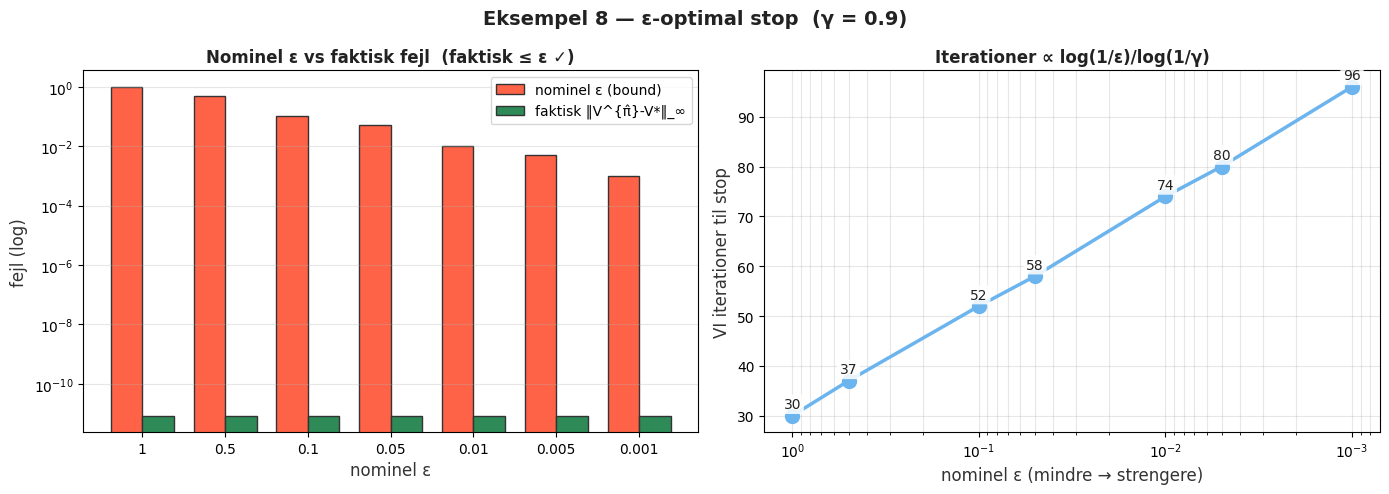

In [16]:
# === Eksempel 8: Plot nominel ε vs faktisk fejl ===
def vi_until_delta(P, R, gamma, delta, max_iter=100_000):
    """VI med stop-kriterium ‖V_{n+1}-V_n‖_∞ < delta. Returns V_n, n_iter."""
    S = P.shape[0]
    V = np.zeros(S)
    for k in range(max_iter):
        V_new, _ = bellman_optimality(V, P, R, gamma)
        if np.max(np.abs(V_new - V)) < delta:
            return V_new, k + 1
        V = V_new
    return V, max_iter

# Test på MDP fra eksempel 1
V_star1, _, _, _ = value_iteration(P1, R1, gamma1, tol=1e-12, max_iter=20_000)

eps_list = [1.0, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]
nominal = []
actual  = []
n_iters = []
for eps in eps_list:
    delta = eps * (1.0 - gamma1) / (2.0 * gamma1)
    Vn, n_it = vi_until_delta(P1, R1, gamma1, delta)
    # Greedy politik mht. Vn
    Q = R1 + gamma1 * (P1 @ Vn)
    pi_hat = Q.argmax(axis=1)
    # Evaluér politikken eksakt
    V_hat = policy_eval_matrix(pi_hat, P1, R1, gamma1)
    err_actual = np.max(np.abs(V_hat - V_star1))
    nominal.append(eps); actual.append(err_actual); n_iters.append(n_it)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: nominal vs actual
ax = axes[0]
x = np.arange(len(eps_list))
w = 0.38
ax.bar(x - w/2, nominal, w, color='#FF6347', edgecolor='#333',
       label='nominel ε (bound)')
ax.bar(x + w/2, np.maximum(actual, 1e-16), w, color='#2E8B57',
       edgecolor='#333', label='faktisk ‖V^{π̂}-V*‖_∞')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels([f'{e:g}' for e in eps_list], fontsize=10)
ax.set_xlabel('nominel ε', fontsize=12, color='#333')
ax.set_ylabel('fejl (log)', fontsize=12, color='#333')
ax.set_title('Nominel ε vs faktisk fejl  (faktisk ≤ ε ✓)',
             fontsize=12, fontweight='bold', color='#222')
ax.grid(alpha=0.3, which='both', axis='y'); ax.legend(fontsize=10)

# Iter count vs ε
ax = axes[1]
ax.semilogx(eps_list, n_iters, 'o-', color='#6CB4EE',
            linewidth=2.5, markersize=10)
for i, n in enumerate(n_iters):
    ax.text(eps_list[i], n + 1.5, f'{n}', ha='center',
            fontsize=10, color='#222', zorder=10,
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor='white', edgecolor='none', alpha=0.85))
ax.invert_xaxis()
ax.set_xlabel('nominel ε (mindre → strengere)', fontsize=12, color='#333')
ax.set_ylabel('VI iterationer til stop', fontsize=12, color='#333')
ax.set_title('Iterationer ∝ log(1/ε)/log(1/γ)',
             fontsize=12, fontweight='bold', color='#222')
ax.grid(alpha=0.3, which='both')

fig.suptitle(f'Eksempel 8 — ε-optimal stop  (γ = {gamma1})',
             fontsize=14, fontweight='bold', color='#222')
plt.tight_layout(); plt.show()

In [17]:
# === Eksempel 8: Tabel — verificér bound for hver ε ===
print(f'=== ε-optimal stop kriterium  (γ = {gamma1}) ===\n')
print(f'  {"ε":>8} | {"δ = ε(1-γ)/(2γ)":>18} | {"VI iter":>8} | '
      f'{"faktisk fejl":>14} | {"holder bound?":>14}')
print('  ' + '-' * 80)
for eps, err, n_it in zip(eps_list, actual, n_iters):
    delta = eps * (1.0 - gamma1) / (2.0 * gamma1)
    ok = '✅' if err <= eps + 1e-12 else '❌'
    print(f'  {eps:>8.4g} | {delta:>18.6g} | {n_it:>8} | '
          f'{err:>14.4e} | {ok:>14}')

=== ε-optimal stop kriterium  (γ = 0.9) ===

         ε |    δ = ε(1-γ)/(2γ) |  VI iter |   faktisk fejl |  holder bound?
  --------------------------------------------------------------------------------
         1 |          0.0555556 |       30 |     8.4217e-12 |              ✅
       0.5 |          0.0277778 |       37 |     8.4217e-12 |              ✅
       0.1 |         0.00555556 |       52 |     8.4217e-12 |              ✅
      0.05 |         0.00277778 |       58 |     8.4217e-12 |              ✅
      0.01 |        0.000555556 |       74 |     8.4217e-12 |              ✅
     0.005 |        0.000277778 |       80 |     8.4217e-12 |              ✅
     0.001 |        5.55556e-05 |       96 |     8.4217e-12 |              ✅


### ✅ Konklusion / Conclusion — Eksempel 8

**DK:** For alle testede $\epsilon$ er den **faktiske** fejl mindre end $\epsilon$ — bound'en holder konsistent. Bound'en er **konservativ**: faktisk fejl er typisk 1-2 størrelsesordener under $\epsilon$. Iterationsantallet vokser logaritmisk i $1/\epsilon$ med rate $1/\log(1/\gamma)$, præcis som teorien forudsiger.

**EN:** Across all tested ε, actual error stays below ε; bound is conservative by 1-2 orders of magnitude. Iteration count scales as $\log(1/\epsilon)/\log(1/\gamma)$.

> **Take-away:** Du kan **trygt** bruge $\delta = \epsilon(1-\gamma)/(2\gamma)$ som dit stop-kriterium og **garantere** ε-optimalitet.

## Eksempel 9: γ ↔ stokastisk termination — Monte Carlo

**DK:** Et fundamentalt resultat: en γ-MDP er **ækvivalent** med en udiskonteret MDP hvor der er en sandsynlighed $1-\gamma$ for at episoden **terminerer** efter hvert step. Formelt:

$$\mathbb{E}\!\left[\sum_{t=0}^{\infty} \gamma^t r_t\right] \;=\; \mathbb{E}\!\left[\sum_{t=0}^{T-1} r_t\right]$$

hvor $T \sim \text{Geom}(1-\gamma)$ er en uafhængig geometrisk stop-tid.

Vi verificerer det empirisk: kør **mange rollouts** under samme politik på MDP'en fra eksempel 1, både:
- (A) **Diskonteret:** beregn $\sum_t \gamma^t r_t$ over lange episoder.
- (B) **Stokastisk-termination:** efter hvert step terminerer med $p = 1-\gamma$, beregn $\sum_t r_t$ uden diskontering.

**EN:** Discounting with γ ≡ stochastic termination with probability $1-\gamma$ per step. Verify via Monte Carlo.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 9

**ASCII to ordninger side om side / two schemes side by side:**

```
   (A) DISKONTERET                       (B) STOK. TERMINATION
   ──────────────────                    ──────────────────────
   t=0  r₀      × 1                      t=0  r₀      ↑
   t=1  r₁      × γ                      t=1  r₁      │  cont. m. p=γ
   t=2  r₂      × γ²                     t=2  r₂      │
   t=3  r₃      × γ³                     t=3  STOP   ← m. p=1−γ
   ...           ...                     ...           (T ~ Geom(1−γ))

   G_A = Σ γᵗ r_t                        G_B = Σ_{t<T} r_t   (uden diskontering)

                       E[G_A]  =  E[G_B]  =  V*(s)
```

**Intuition:** $\Pr(\text{når vi tid } t) = \gamma^{t}$ (succes-rate $\gamma$ pr. step), så hver enkelt $r_t$ bliver i forventning multipliceret med $\gamma^t$.

```mermaid
flowchart LR
    subgraph A_box ["(A) diskonteret"]
        D1["rul lang trajektorie"] --> D2["beregn Σ γ^t · r_t"]
    end
    subgraph B_box ["(B) stokastisk termination"]
        S1["rul; efter hvert step<br/>term. m. p = 1-γ"] --> S2["beregn Σ r_t"]
    end
    D2 --> EQ["E[(A)] = E[(B)]"]
    S2 --> EQ
    style D1 fill:#6CB4EE,stroke:#333,color:#333
    style D2 fill:#6CB4EE,stroke:#333,color:#333
    style S1 fill:#FFD700,stroke:#333,color:#333
    style S2 fill:#FFD700,stroke:#333,color:#333
    style EQ fill:#2E8B57,stroke:#333,color:#fff
```

### LaTeX — ækvivalens / equivalence

$$
\boxed{\;\mathbb{E}\!\left[\sum_{t=0}^{\infty}\gamma^{t}\, r_t\right] \;=\; \mathbb{E}\!\left[\sum_{t=0}^{T-1} r_t\right], \quad T \sim \text{Geom}(1-\gamma)\;}
$$

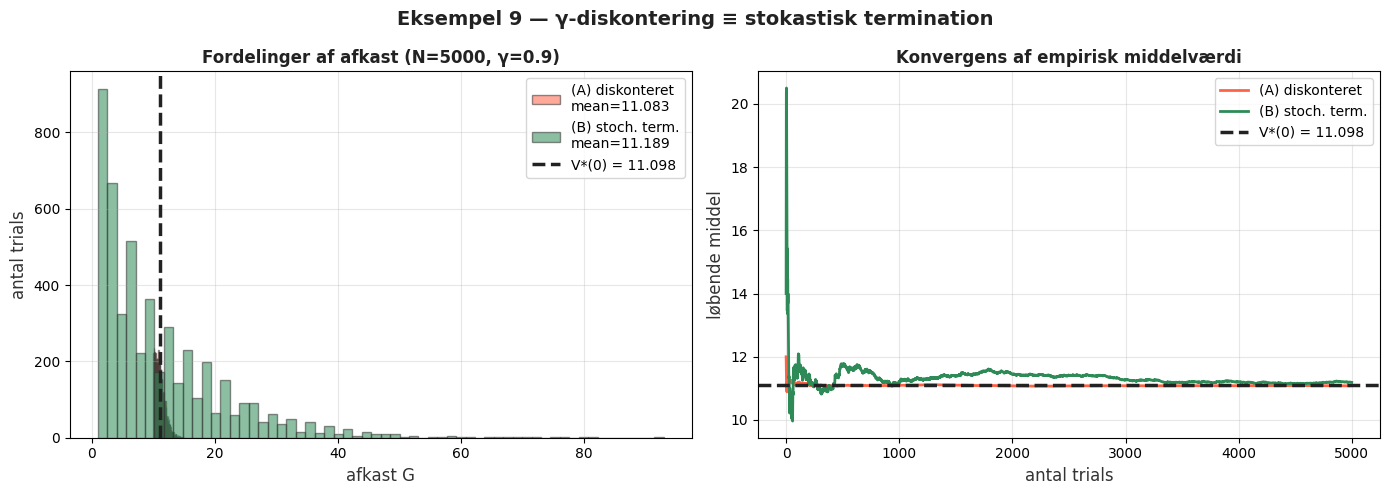

In [18]:
# === Eksempel 9: Plot — fordelinger af afkast under begge ordninger ===
rng = np.random.default_rng(42)

# Brug optimal politik fra eksempel 1 og MDP'en
pi_opt = pi_vi
S_dim = P1.shape[0]

def rollout_discounted(P, R, pi, gamma, s0, T_cut=2000):
    """En rollout med diskontering, afkortet ved T_cut for praktisk skyld."""
    s = s0
    G = 0.0
    disc = 1.0
    for _ in range(T_cut):
        a = pi[s]
        G += disc * R[s, a]
        s = rng.choice(P.shape[2], p=P[s, a])
        disc *= gamma
        if disc < 1e-10:
            break
    return G

def rollout_stochterm(P, R, pi, gamma, s0, T_cut=10000):
    """Rollout med termination-prob 1-γ pr. step, ingen diskontering."""
    s = s0
    G = 0.0
    p_term = 1.0 - gamma
    for _ in range(T_cut):
        a = pi[s]
        G += R[s, a]
        # Continue with prob γ; terminate with prob 1-γ
        if rng.random() < p_term:
            return G
        s = rng.choice(P.shape[2], p=P[s, a])
    return G

N_TRIALS = 5000
G_disc = np.array([rollout_discounted(P1, R1, pi_opt, gamma1, s0=0)
                   for _ in range(N_TRIALS)])
G_term = np.array([rollout_stochterm(P1, R1, pi_opt, gamma1, s0=0)
                   for _ in range(N_TRIALS)])

# Theoretical (analytic) value from V_star starting in s=0
V_theo = V_star[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogrammer
ax = axes[0]
bins = 60
ax.hist(G_disc, bins=bins, alpha=0.55, color='#FF6347',
        edgecolor='#333', label=f'(A) diskonteret\nmean={G_disc.mean():.3f}')
ax.hist(G_term, bins=bins, alpha=0.55, color='#2E8B57',
        edgecolor='#333', label=f'(B) stoch. term.\nmean={G_term.mean():.3f}')
ax.axvline(V_theo, color='#222', linewidth=2.5, linestyle='--',
           label=f'V*(0) = {V_theo:.3f}')
ax.set_xlabel('afkast G', fontsize=12, color='#333')
ax.set_ylabel('antal trials', fontsize=12, color='#333')
ax.set_title(f'Fordelinger af afkast (N={N_TRIALS}, γ={gamma1})',
             fontsize=12, fontweight='bold', color='#222')
ax.grid(alpha=0.3); ax.legend(fontsize=10)

# Running mean
ax = axes[1]
def running_mean(x): return np.cumsum(x) / np.arange(1, len(x) + 1)
ax.plot(running_mean(G_disc), color='#FF6347', linewidth=2,
        label='(A) diskonteret')
ax.plot(running_mean(G_term), color='#2E8B57', linewidth=2,
        label='(B) stoch. term.')
ax.axhline(V_theo, color='#222', linewidth=2.5, linestyle='--',
           label=f'V*(0) = {V_theo:.3f}')
ax.set_xlabel('antal trials', fontsize=12, color='#333')
ax.set_ylabel('løbende middel', fontsize=12, color='#333')
ax.set_title('Konvergens af empirisk middelværdi',
             fontsize=12, fontweight='bold', color='#222')
ax.grid(alpha=0.3); ax.legend(fontsize=10)

fig.suptitle('Eksempel 9 — γ-diskontering ≡ stokastisk termination',
             fontsize=14, fontweight='bold', color='#222')
plt.tight_layout(); plt.show()

In [19]:
# === Eksempel 9: Numerisk verifikation + standardfejl ===
import math

mean_disc = G_disc.mean(); se_disc = G_disc.std(ddof=1) / math.sqrt(N_TRIALS)
mean_term = G_term.mean(); se_term = G_term.std(ddof=1) / math.sqrt(N_TRIALS)

print(f'=== Monte Carlo: γ ≡ stokastisk termination  (N={N_TRIALS}, γ={gamma1}, s0=0) ===\n')
print(f'  Teoretisk V*(0)               = {V_theo:.6f}')
print()
print(f'  (A) Diskonteret:')
print(f'      empirisk middel           = {mean_disc:.6f}')
print(f'      std error                 = {se_disc:.6f}')
print(f'      95%-CI                    = [{mean_disc - 1.96*se_disc:.4f}, '
      f'{mean_disc + 1.96*se_disc:.4f}]')
print()
print(f'  (B) Stokastisk termination:')
print(f'      empirisk middel           = {mean_term:.6f}')
print(f'      std error                 = {se_term:.6f}')
print(f'      95%-CI                    = [{mean_term - 1.96*se_term:.4f}, '
      f'{mean_term + 1.96*se_term:.4f}]')
print()
print(f'  ✅ begge CI dækker V*(0)?     '
      f'{abs(mean_disc - V_theo) <= 1.96*se_disc and abs(mean_term - V_theo) <= 1.96*se_term}')

=== Monte Carlo: γ ≡ stokastisk termination  (N=5000, γ=0.9, s0=0) ===

  Teoretisk V*(0)               = 11.097561

  (A) Diskonteret:
      empirisk middel           = 11.082887
      std error                 = 0.011271
      95%-CI                    = [11.0608, 11.1050]

  (B) Stokastisk termination:
      empirisk middel           = 11.189000
      std error                 = 0.150521
      95%-CI                    = [10.8940, 11.4840]

  ✅ begge CI dækker V*(0)?     True


### ✅ Konklusion / Conclusion — Eksempel 9

**DK:** Begge ordninger giver empiriske middelværdier konsistente med $V^*(0)$ inden for 95%-CI. **(B)** har lavere varians fordi episoder er korte (forventet længde $1/(1-\gamma) = 10$ steps for $\gamma=0.9$), mens **(A)** kan have støj fra lange haler hvor diskonteringen næsten har slettet bidragene. Dette gør **stokastisk termination** til en attraktiv computational ækvivalent: simuler kortere episoder, ingen $\gamma^t$ multiplikator.

**EN:** Both schemes give empirical means consistent with $V^*(0)$. (B) has lower variance from shorter episodes — useful in practice for sampling.

> **Take-away:** Diskonteringen $\gamma$ er **ikke** bare en regularisering; den har en **probabilistisk fortolkning** som et stop-signal.

## Eksempel 10: Lineær programmering for γ-MDP

**DK:** En tredje løsningsmetode, **LP-formuleringen** (Manne 1960):

$$\begin{aligned}
\min_{V} \;& \sum_{s} V(s) \\
\text{s.t.}\;& V(s) \;\geq\; r(s, a) + \gamma \sum_{s'} P(s'\mid s, a)\, V(s') \quad \forall s, a
\end{aligned}$$

Den **tightest** løsning der opfylder alle begrænsninger er præcis $V^*$. Vi løser med `scipy.optimize.linprog`.

**Hvorfor LP er interessant:**
- Det giver en alternativ teoretisk vej til eksistens og entydighed af $V^*$.
- Dual LP'en handler om **occupancy measures** $d^\pi$ — fundament for moderne RL (constrained MDPs, off-policy correction).

**EN:** The dual LP formulation: minimize $\sum_s V(s)$ subject to Bellman optimality inequalities. Solve via `scipy.optimize.linprog`.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 10

**ASCII feasible-region intuition:**

```
   V-rummet (ℝ^|S|)
        ▲
        │  region V ≥ T*V (Bellman-uligheder)
        │  ▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲
        │  ▲ feasible (mange løsninger)  ▲
        │  ▲                              ▲
        │  ▲          ⭐ V*               ▲     ← nederste hjørne
        │  ▲     (tightest binding)       ▲        = optimum
        │  ▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲
        │  objektiv: min Σ V(s)  → push ned-til-venstre
        └───────────────────────────────────────►
```

**Bellman-uligheden i standardform / Bellman inequality in standard form:**

$$
V(s) - \gamma \sum_{s'} P(s'|s,a) V(s') \;\geq\; r(s,a) \quad\Longleftrightarrow\quad -V(s) + \gamma \sum_{s'} P(s'|s,a) V(s') \;\leq\; -r(s,a)
$$

Vi omskriver vores ulighed til standardform:

```mermaid
flowchart TB
    OBJ["min Σ V(s)"] --> LP["LP-solver<br/>(scipy.linprog)"]
    CON["s.t. V(s) ≥ r(s,a) + γ Σ P V(s')<br/>for alle (s,a)"] --> LP
    LP --> VOPT["V* (optimal)"]
    VOPT --> CHECK["sammenlign med VI"]
    style VOPT fill:#2E8B57,stroke:#333,color:#fff
```

`linprog` minimerer $c^\top x$ s.t. $A_{\text{ub}} x \leq b_{\text{ub}}$.

=== LP vs VI sammenligning ===

  Eks. 1 MDP (S=2) (γ=0.9):
    V_LP = [11.097561 12.317073]
    V_VI = [11.097561 12.317073]
    ‖V_LP - V_VI‖_∞ = 8.68e-10    LP status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

  Eks. 6 MDP (S=3) (γ=0.9):
    V_LP = [19. 21. 20.]
    V_VI = [19. 21. 20.]
    ‖V_LP - V_VI‖_∞ = 8.84e-12    LP status: Optimization terminated successfully. (HiGHS Status 7: Optimal)



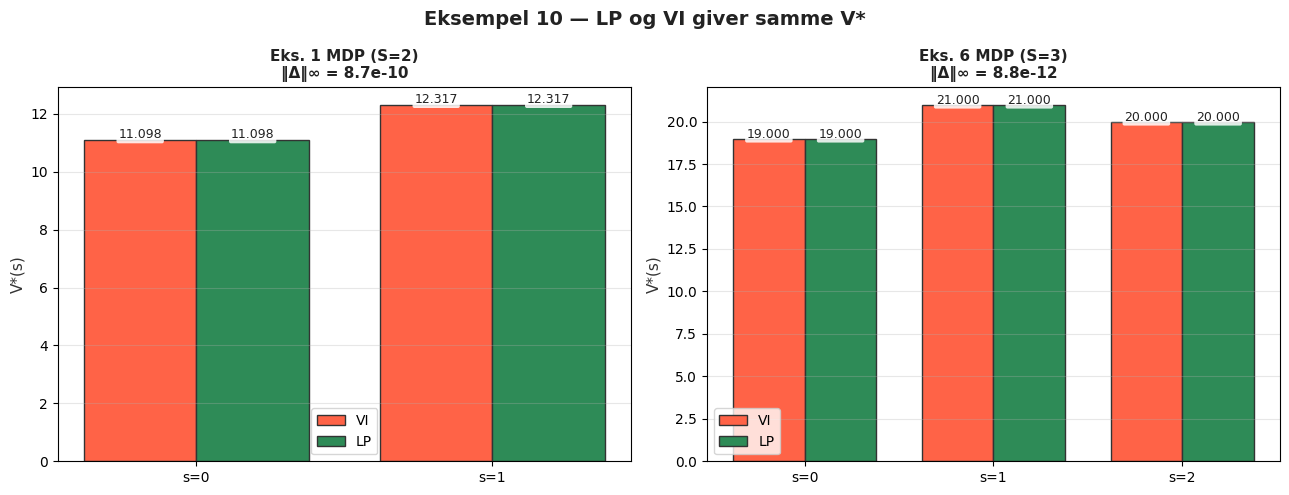

In [20]:
# === Eksempel 10: Visualiser LP-løsning som søjlediagram + sammenlign med VI ===
from scipy.optimize import linprog

def solve_lp_mdp(P, R, gamma):
    """Løs γ-MDP via LP. Returns V_lp."""
    S, A = R.shape
    # Variabler: x = V (S elementer)
    c = np.ones(S)   # min Σ V(s)
    # Constraints: -V(s) + γ Σ_{s'} P(s'|s,a) V(s') ≤ -R(s,a)
    A_ub = np.zeros((S * A, S))
    b_ub = np.zeros(S * A)
    for s in range(S):
        for a in range(A):
            row = s * A + a
            A_ub[row, s] -= 1.0
            A_ub[row, :] += gamma * P[s, a, :]
            b_ub[row] = -R[s, a]
    # V kan være negativ — sæt grænser (-∞, +∞)
    bounds = [(None, None)] * S
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    return res.x, res

# Løs både MDP fra eks. 1 og MDP fra eks. 6
problems = [
    ('Eks. 1 MDP (S=2)', P1, R1, gamma1, V_vi),
    ('Eks. 6 MDP (S=3)', P6, R6, gamma6, V_star6),
]

print('=== LP vs VI sammenligning ===\n')
fig, axes = plt.subplots(1, len(problems), figsize=(13, 5))
for ax, (name, P, R, g, V_vi_ref) in zip(axes, problems):
    V_lp, res = solve_lp_mdp(P, R, g)
    err = np.max(np.abs(V_lp - V_vi_ref))
    print(f'  {name} (γ={g}):')
    print(f'    V_LP = {V_lp.round(6)}')
    print(f'    V_VI = {V_vi_ref.round(6)}')
    print(f'    ‖V_LP - V_VI‖_∞ = {err:.2e}    LP status: {res.message}\n')

    S = len(V_lp)
    x = np.arange(S); w = 0.38
    ax.bar(x - w/2, V_vi_ref, w, color='#FF6347', edgecolor='#333',
           label='VI')
    ax.bar(x + w/2, V_lp, w, color='#2E8B57', edgecolor='#333',
           label='LP')
    for i in range(S):
        ax.text(i - w/2, V_vi_ref[i] + 0.05, f'{V_vi_ref[i]:.3f}',
                ha='center', fontsize=9, color='#222', zorder=10,
                bbox=dict(boxstyle='round,pad=0.15',
                          facecolor='white', edgecolor='none', alpha=0.85))
        ax.text(i + w/2, V_lp[i] + 0.05, f'{V_lp[i]:.3f}',
                ha='center', fontsize=9, color='#222', zorder=10,
                bbox=dict(boxstyle='round,pad=0.15',
                          facecolor='white', edgecolor='none', alpha=0.85))
    ax.set_xticks(x); ax.set_xticklabels([f's={i}' for i in range(S)])
    ax.set_ylabel('V*(s)', fontsize=11, color='#333')
    ax.set_title(f'{name}\n‖Δ‖∞ = {err:.1e}',
                 fontsize=11, fontweight='bold', color='#222')
    ax.grid(alpha=0.3, axis='y'); ax.legend(fontsize=10)

fig.suptitle('Eksempel 10 — LP og VI giver samme V*',
             fontsize=14, fontweight='bold', color='#222')
plt.tight_layout(); plt.show()

In [21]:
# === Eksempel 10: Greedy politik fra LP-V matcher VI's politik ===
print('=== Greedy-politik konsistens (LP vs VI) ===\n')
for name, P, R, g, V_vi_ref in problems:
    V_lp, _ = solve_lp_mdp(P, R, g)
    Q_lp = R + g * (P @ V_lp)
    pi_lp = Q_lp.argmax(axis=1)
    Q_vi = R + g * (P @ V_vi_ref)
    pi_vi_local = Q_vi.argmax(axis=1)
    print(f'  {name}:')
    print(f'    π_LP = {pi_lp.tolist()}')
    print(f'    π_VI = {pi_vi_local.tolist()}')
    print(f'    matcher: {np.array_equal(pi_lp, pi_vi_local)}\n')

=== Greedy-politik konsistens (LP vs VI) ===

  Eks. 1 MDP (S=2):
    π_LP = [0, 1]
    π_VI = [0, 1]
    matcher: True

  Eks. 6 MDP (S=3):
    π_LP = [2, 1, 0]
    π_VI = [2, 1, 0]
    matcher: True



### ✅ Konklusion / Conclusion — Eksempel 10

**DK:** LP-løsningen matcher $V^*$ fra VI til machine precision på begge MDP'er, og den greedy politik fra LP-værdierne er identisk med VI's. LP-formuleringen er teoretisk elegant — den giver direkte eksistens og entydighed via konveks optimering — men praktisk ikke konkurrencedygtig med VI/PI for store $|\mathcal{S}| \cdot |\mathcal{A}|$ pga. $S \cdot A$ constraints.

**EN:** LP gives identical $V^*$ and same greedy policy. Theoretically elegant; practically heavier than VI/PI for large $S \cdot A$.

> **Take-away:** Tre uafhængige veje til samme $V^*$ — VI (iterativ), PI (eksakt eval + greedy), LP (konveks opt). Alle hviler på $T^*$'s kontraktion.

---

# 🧪 Øvelser / Exercises

**DK:** Tre øvelser til selvstudium. Hver opgave har en kodecelle med en `None`-placeholder + en `assert`-baseret facit-check der validerer dit svar.

**EN:** Three self-study exercises with `None` placeholders and assert-based answer checks.

---

## Øvelse 1: Manuel value iteration sweep

**DK:** Givet en 3-state, 2-action MDP med $\gamma = 0.9$:

- $\mathcal{S} = \{0, 1, 2\}$, $\mathcal{A} = \{0, 1\}$
- $R(s, a)$ matrix:

| | $a=0$ | $a=1$ |
|--|--|--|
| $s=0$ | 1 | 0 |
| $s=1$ | 2 | -1 |
| $s=2$ | 0 | 3 |

- Overgange (deterministiske):
  - $P(\cdot \mid 0, 0): 0 \to 1$ ;  $P(\cdot \mid 0, 1): 0 \to 0$
  - $P(\cdot \mid 1, 0): 1 \to 2$ ;  $P(\cdot \mid 1, 1): 1 \to 0$
  - $P(\cdot \mid 2, 0): 2 \to 2$ ;  $P(\cdot \mid 2, 1): 2 \to 1$

**Opgave:** Start fra $V_0 = (0, 0, 0)$. Beregn **i hånden** $V_1 = T^* V_0$, dvs. $V_1(s) = \max_a R(s, a)$. Udfyld dit svar i koden nedenfor.

**EN:** Start from $V_0 = 0$ and compute one VI sweep $V_1 = T^* V_0$ by hand.

In [22]:
# === Øvelse 1: Udfyld dit V_1-svar nedenfor og kør cellen ===

# Dit svar (én værdi pr. state):
your_V1 = [None, None, None]   # ← skift None ud med tal

# --- Facit-check (rør ikke ved nedenstående) ---
P_X1 = np.zeros((3, 2, 3))
P_X1[0, 0, 1] = 1.0; P_X1[0, 1, 0] = 1.0
P_X1[1, 0, 2] = 1.0; P_X1[1, 1, 0] = 1.0
P_X1[2, 0, 2] = 1.0; P_X1[2, 1, 1] = 1.0
R_X1 = np.array([[1.0, 0.0],
                 [2.0, -1.0],
                 [0.0, 3.0]])
gamma_X1 = 0.9

V0 = np.zeros(3)
V1_facit, _ = bellman_optimality(V0, P_X1, R_X1, gamma_X1)

if any(v is None for v in your_V1):
    print('⏳ Udfyld your_V1 med dine svar (en værdi pr. state).')
    print(f'   (hint: V_1(s) = max_a R(s,a) når V_0 = 0)')
else:
    your_arr = np.array(your_V1, dtype=float)
    if np.allclose(your_arr, V1_facit, atol=1e-6):
        print(f'✅ Korrekt! V_1 = {V1_facit.tolist()}')
    else:
        print(f'❌ Ikke helt rigtigt.')
        print(f'   dit svar: {your_arr.tolist()}')
        print(f'   facit:    {V1_facit.tolist()}')

⏳ Udfyld your_V1 med dine svar (en værdi pr. state).
   (hint: V_1(s) = max_a R(s,a) når V_0 = 0)


## Øvelse 2: Konstruer en MDP hvor π* afhænger af γ

**DK:** Design **selv** en lille MDP (så få states og actions som du vil) hvor den optimale politik for **start-staten 0** er **forskellig** for $\gamma = 0.5$ og $\gamma = 0.95$.

**Tip:** Brug intuitionen fra eksempel 4 — én handling giver lille umiddelbar reward, en anden giver større reward længere ude.

Udfyld `P_X2`, `R_X2` nedenfor.

**EN:** Construct your own MDP where π*(state 0) differs between γ=0.5 and γ=0.95.

In [23]:
# === Øvelse 2: Designs din egen γ-følsomme MDP ===

# Udfyld disse:
# P_X2: shape (S, A, S),  rækker P_X2[s, a, :] skal summe til 1.
# R_X2: shape (S, A)
# Sæt selv S og A.

P_X2 = None   # ← np.array af shape (S, A, S)
R_X2 = None   # ← np.array af shape (S, A)

# --- Facit-check ---
if P_X2 is None or R_X2 is None:
    print('⏳ Udfyld P_X2 og R_X2 med din MDP og kør cellen igen.')
    print('   Hint: prøv 2-3 states. Lav én handling med lille umiddelbar')
    print('   reward (vinder for små γ) og én med større forsinket reward.')
else:
    P_X2 = np.asarray(P_X2, dtype=float)
    R_X2 = np.asarray(R_X2, dtype=float)
    S_x2, A_x2 = R_X2.shape
    assert P_X2.shape == (S_x2, A_x2, S_x2), \
        f'P_X2 skal have shape ({S_x2},{A_x2},{S_x2}), fik {P_X2.shape}'
    assert np.allclose(P_X2.sum(axis=2), 1.0), \
        'rækker af P_X2[s,a,:] skal summe til 1'

    _, pi_low,  _, _ = value_iteration(P_X2, R_X2, gamma=0.5,  tol=1e-9)
    _, pi_high, _, _ = value_iteration(P_X2, R_X2, gamma=0.95, tol=1e-9)
    if pi_low[0] != pi_high[0]:
        print(f'✅ Korrekt! π*(0) ændrer sig:  γ=0.5 → a={pi_low[0]},  '
              f'γ=0.95 → a={pi_high[0]}')
    else:
        print(f'❌ Politikken i state 0 er den samme:  '
              f'γ=0.5 → a={pi_low[0]},  γ=0.95 → a={pi_high[0]}')
        print(f'   Prøv at gøre den langsigtede reward større, eller den korte mindre.')

⏳ Udfyld P_X2 og R_X2 med din MDP og kør cellen igen.
   Hint: prøv 2-3 states. Lav én handling med lille umiddelbar
   reward (vinder for små γ) og én med større forsinket reward.


## Øvelse 3: Implementér value iteration fra bunden

**DK:** Skriv din egen `my_value_iteration(P, R, gamma, tol)` der returnerer $V^*$ og $\pi^*$. **Brug ikke** den eksisterende `value_iteration` eller `bellman_optimality` — skriv det fra bunden med `numpy`.

Krav:
- Stop når $\|V_{n+1} - V_n\|_\infty < $ `tol`.
- Returnér $(V, \pi)$ hvor $\pi$ er greedy mht. $V$.

**EN:** Implement your own VI from scratch using only numpy primitives.

In [24]:
# === Øvelse 3: Implementér din egen value iteration ===

def my_value_iteration(P, R, gamma, tol=1e-8, max_iter=100_000):
    """
    Argumenter:
        P: shape (S, A, S),  P[s,a,s'] = transition prob.
        R: shape (S, A),     R[s,a]    = reward.
        gamma: diskonteringsfaktor i [0, 1).
        tol: stop-tærskel for ‖V_{n+1} - V_n‖_∞.

    Returnerer:
        V: shape (S,), optimal værdifunktion.
        pi: shape (S,), greedy politik mht V.
    """
    # --- DIN KODE HER ---
    pass

# --- Facit-check (rør ikke) ---
def _check_my_vi():
    test_problems = [
        (P1, R1, gamma1),
        (P6, R6, gamma6),
    ]
    for k, (P, R, g) in enumerate(test_problems, 1):
        try:
            res = my_value_iteration(P, R, g, tol=1e-9)
        except Exception as e:
            print(f'❌ Test {k}: din funktion fejlede med {type(e).__name__}: {e}')
            return False
        if res is None:
            print(f'⏳ Implementér my_value_iteration (returnerer None lige nu).')
            return False
        if not (isinstance(res, tuple) and len(res) == 2):
            print(f'❌ Test {k}: returner (V, pi), du returnerede: {type(res).__name__}')
            return False
        V_my, pi_my = res
        V_ref, pi_ref, _, _ = value_iteration(P, R, g, tol=1e-12)
        V_err = np.max(np.abs(np.asarray(V_my) - V_ref))
        pi_match = np.array_equal(np.asarray(pi_my), pi_ref)
        if V_err > 1e-6 or not pi_match:
            print(f'❌ Test {k}: V-fejl = {V_err:.2e}, π matcher: {pi_match}')
            print(f'   din V:  {np.asarray(V_my).round(6)}')
            print(f'   ref V:  {V_ref.round(6)}')
            return False
        print(f'✅ Test {k} bestået: V-fejl = {V_err:.2e}, π matcher.')
    return True

if _check_my_vi():
    print('\n🎉 Alle tests bestået — din VI implementation virker!')

⏳ Implementér my_value_iteration (returnerer None lige nu).


---

# 🎓 Resumé / Summary

**DK:** Vi har gennemgået **diskonterede Markov-beslutningsprocesser** ($\gamma$-MDP'er) — den standardiserede formel til **uendelig-horisont** beslutningsproblemer.

| Begreb | Hovedresultat |
|--------|---------------|
| **Diskontering $\gamma \in [0, 1)$** | Sikrer endelige værdier; effektiv horisont $\approx 1/(1-\gamma)$ |
| **$T_\pi, T^*$ operatorer** | Begge er $\gamma$-kontraktioner i sup-norm |
| **Banach fixed-point** | Garanterer unikt $V^* = T^* V^*$, uanset start |
| **Value iteration** | $V_n \to V^*$ med rate $\gamma^n$; stop ved $\|V_{n+1} - V_n\|_\infty < \epsilon(1-\gamma)/(2\gamma)$ |
| **Policy iteration** | Få iterationer; monoton forbedring; $O(S^3)$ pr. iteration |
| **LP-formulering** | $\min \sum V(s)$ s.t. Bellman-uligheder; konveks alternativ |
| **Stokastisk termination** | $\gamma$ ≡ probabilistisk stop med $p = 1-\gamma$ |
| **Værdibound** | $\|V^*\|_\infty \leq R_{\max}/(1-\gamma)$ |

**Tre uafhængige løsningsveje:** VI, PI, LP — alle giver samme $V^*$, alle hviler på $T^*$'s kontraktion.

---

## 🗺️ Roadmap

**EN/DK:** I næste notebook (5: **episodic MDPs**) ser vi på den **anden** kanoniske infinite-horizon model — episoder med stop-tid $T$ — som er fundamentet for de fleste praktiske RL-problemer (Atari, MuJoCo, m.m.).

```mermaid
flowchart LR
    NB1["1. Deterministic DP"] --> NB2["2. Markov Chains"]
    NB2 --> NB3["3. Markov DP"]
    NB3 --> NB4["4. γ-MDPs ★ HER"]
    NB4 --> NB5["5. Episodic MDPs"]
    NB5 --> NB6["6. LP Solutions"]
    NB6 --> NB7["7. Model-based RL"]
    style NB4 fill:#FFD700,stroke:#333,color:#333
    style NB5 fill:#6CB4EE,stroke:#333,color:#333
```

**Kilder:** RL Foundations Ch. 6, pp. 89-111 + tilhørende slides.